# PV-AI Forecast
## Prévision de la production solaire à partir de données réelles

**Auteur : Serigne Fallou Faye**  
**Date : Septembre 2026**

### Présentation

Ce notebook montre comment préparer des données solaires, calculer des informations physiques sur le soleil et entraîner des modèles qui estiment la production photovoltaïque future.

Le programme utilise quatre sources de données :

- **A - SolarTech Lab** : mesures de puissance et de météo à Milan. La puissance `PV_Power` est fournie en watts et est convertie en kilowatts.
- **B - UNISOLAR** : production, météo et irradiance d'un site situé à Melbourne.
- **C - Plant 1** : production de plusieurs onduleurs en Inde. Les onduleurs sont regroupés pour obtenir une puissance totale.
- **D - BR-PVGen** : données électriques de 51 centrales brésiliennes. Le notebook charge les 51 fichiers et utilise leurs valeurs électriques pour les analyses disponibles.

Le traitement suit toujours le même ordre :

1. trouver les fichiers de données ;
2. lire et vérifier les colonnes ;
3. convertir les unités ;
4. remettre les dates sur un pas de 15 minutes lorsque cela est prévu ;
5. traiter les valeurs manquantes ;
6. calculer le facteur de charge ;
7. créer les variables utiles aux modèles ;
8. séparer les données dans le temps ;
9. entraîner les modèles ;
10. afficher les erreurs et les graphiques.

L'objectif est que chaque résultat puisse être relié à une donnée, une formule et une étape de calcul clairement identifiées.

## Section 1 : Préparer l'environnement

Cette section installe les bibliothèques utilisées par le notebook.

- `pandas` lit et organise les tableaux de données.
- `numpy` réalise les calculs numériques.
- `scikit-learn` fournit les modèles classiques et les mesures d'erreur.
- `xgboost` fournit un modèle d'apprentissage basé sur plusieurs arbres de décision.
- `tensorflow` et `keras` servent à construire les réseaux LSTM et GRU.
- `shap` aide à comprendre l'influence des variables sur les prédictions.

Le programme définit aussi plusieurs graines aléatoires. Une graine permet de retrouver des résultats proches lorsque le notebook est relancé.

In [120]:
# Installation silencieuse des bibliothèques nécessaires
!pip install -q xgboost shap scikit-learn


In [121]:
import os
import sys
import glob
import math
import time
import warnings
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Algorithmes de Machine Learning & Métriques d'évaluation
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Algorithmes de Deep Learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# Bibliothèque d'explicabilité par valeurs de Shapley
import shap

# Configuration esthétique et ergonomique
pd.set_option('display.max_columns', 35)
pd.set_option('display.width', 130)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
warnings.filterwarnings('ignore', category=FutureWarning)

# =====================================================================
# Protocole Multi-Graines (Point 9) : 5 graines pour évaluer moyenne ± std
# =====================================================================
SEEDS = [42, 101, 202, 303, 404]
DEFAULT_SEED = SEEDS[0]

def set_all_seeds(seed: int = DEFAULT_SEED):
    """
    Fixe de manière déterministe toutes les graines aléatoires des bibliothèques
    pour garantir une reproductibilité parfaite des calculs numériques.

    Args:
        seed (int): Valeur entière de la graine aléatoire.
    """
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_all_seeds(DEFAULT_SEED)

print("=" * 80)
print("✓ Environnement scientifique configuré avec succès.")
print(f"✓ Version Python       : {sys.version.split()[0]}")
print(f"✓ Version TensorFlow   : {tf.__version__}")
print(f"✓ Version XGBoost      : {__import__('xgboost').__version__}")
print(f"✓ Version SHAP         : {__import__('shap').__version__}")
print(f"✓ Graines d'évaluation : {SEEDS} (défaut: {DEFAULT_SEED})")
print("=" * 80)

✓ Environnement scientifique configuré avec succès.
✓ Version Python       : 3.13.15
✓ Version TensorFlow   : 2.20.0
✓ Version XGBoost      : 3.4.1
✓ Version SHAP         : 0.52.0
✓ Graines d'évaluation : [42, 101, 202, 303, 404] (défaut: 42)


## Section 2 : Trouver les fichiers de données

La fonction de cette section détecte l'environnement utilisé : Google Colab ou ordinateur local.

Sur Google Colab, elle monte Google Drive et cherche les fichiers dans `MyDrive`. Sur l'ordinateur local, elle cherche les fichiers dans le dossier du projet.

Le programme recherche les fichiers par leur nom. Il accepte aussi les cas où un fichier CSV se trouve dans un dossier qui porte le même nom.

La sortie de la cellule indique, pour chaque fichier, s'il a été trouvé. Cette vérification est importante : les étapes suivantes ne peuvent fonctionner que si les chemins sont corrects.

In [122]:
def setup_environment() -> Dict[str, Optional[str]]:
    """
    Détecte automatiquement l'environnement d'exécution et recherche les datasets
    directement dans MyDrive, y compris dans les dossiers issus d'une décompression.
    """
    is_colab = os.path.isdir('/content') and 'google.colab' in sys.modules

    if is_colab:
        print(">> Environnement détecté : Google Colab")
        from google.colab import drive
        drive.mount('/content/drive')
        base_dir = "/content/drive/MyDrive"

        if not os.path.exists("UNISOLAR"):
            print(">> Clonage du dépôt UNISOLAR pour les fichiers météo/irradiance complémentaires...")
            !git clone -q https://github.com/CDAC-lab/UNISOLAR.git
    else:
        print(">> Environnement détecté : Machine Locale (Windows/Linux)")
        base_dir = r"C:\Users\SERIGNE FALLOU FAYE\Documents\IA SOLAR"

    def find_file(filename: str) -> Optional[str]:
        """Recherche un fichier par nom, y compris dans un dossier du même nom."""
        direct = os.path.join(base_dir, filename)
        if os.path.isfile(direct):
            return direct
        matches = glob.glob(os.path.join(base_dir, "**", filename), recursive=True)
        files = [match for match in matches if os.path.isfile(match)]
        return files[0] if files else None

    def find_directory(dirname: str) -> Optional[str]:
        """Recherche un dossier par nom dans l'arborescence des données."""
        direct = os.path.join(base_dir, dirname)
        if os.path.isdir(direct):
            return direct
        matches = glob.glob(os.path.join(base_dir, "**", dirname), recursive=True)
        dirs = [match for match in matches if os.path.isdir(match)]
        return dirs[0] if dirs else None

    paths = {
        "solartech": find_file("Dataset-SolarTechLab.csv"),
        "unisolar_gen": find_file("Solar_Energy_Generation.csv"),
        "unisolar_sites": find_file("Solar_Site_Details.csv"),
        "unisolar_weather": find_file("Weather_Data_reordered_all.csv"),
        "unisolar_irr": find_file("Solar_Irradiance.csv"),
        "plant1": find_file("Plant_1_Generation_Data.csv"),
        "br_pvgen_dir": find_directory("BR-PVGen_inverter")
    }

    # Le dépôt cloné peut fournir les fichiers météo/irradiance manquants.
    if paths["unisolar_weather"] is None:
        candidate = os.path.join("UNISOLAR", "data", "Weather_data_sub.csv")
        if os.path.isfile(candidate):
            paths["unisolar_weather"] = candidate
    if paths["unisolar_irr"] is None:
        candidate = os.path.join("UNISOLAR", "data", "Solar_Irradiance.csv")
        if os.path.isfile(candidate):
            paths["unisolar_irr"] = candidate

    print("\nTableau d'identification des fichiers de données :")
    print("-" * 80)
    for key, value in paths.items():
        status = "TROUVÉ [OK]" if value and os.path.exists(value) else "MANQUANT [!]"
        print(f"  {key:<18} : {status} -> {value}")
    print("-" * 80)
    return paths

DATA_PATHS = setup_environment()

>> Environnement détecté : Google Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Tableau d'identification des fichiers de données :
--------------------------------------------------------------------------------
  solartech          : TROUVÉ [OK] -> /content/drive/MyDrive/IA SOLAR/Dataset-SolarTechLab.csv
  unisolar_gen       : TROUVÉ [OK] -> /content/drive/MyDrive/IA SOLAR/Solar_Energy_Generation.csv/Solar_Energy_Generation.csv
  unisolar_sites     : TROUVÉ [OK] -> /content/drive/MyDrive/IA SOLAR/Solar_Site_Details.csv
  unisolar_weather   : TROUVÉ [OK] -> /content/drive/MyDrive/IA SOLAR/Weather_Data_reordered_all.csv/Weather_Data_reordered_all.csv
  unisolar_irr       : TROUVÉ [OK] -> UNISOLAR/data/Solar_Irradiance.csv
  plant1             : TROUVÉ [OK] -> /content/drive/MyDrive/IA SOLAR/Plant_1_Generation_Data.csv/Plant_1_Generation_Data.csv
  br_pvgen_dir       : TROUVÉ [OK] -> /content/drive/

## Section 3 : Lire et nettoyer les données

Cette section transforme les quatre sources en tableaux ayant des noms de colonnes communs.

Pour chaque dataset, le programme :

1. lit les dates et les mesures ;
2. trie les lignes dans l'ordre du temps ;
3. convertit la puissance en kilowatts lorsque la source est en watts ;
4. regroupe les onduleurs quand une centrale contient plusieurs onduleurs ;
5. vérifie le pas de temps ;
6. distingue une vraie valeur nulle d'une valeur manquante ;
7. produit un tableau d'audit.

Pour SolarTech Lab, les valeurs de `PV_Power` suivent le chemin `power_w`, puis `power_kw = power_w / 1000`.

Pour Plant 1, les colonnes `AC_POWER` et `DC_POWER` sont agrégées puis converties selon le paramètre `PLANT1_POWER_UNIT`. Le CSV local ne porte pas l'unité dans son en-tête ; la cellule affiche donc l'unité configurée et la puissance maximale obtenue. Cette valeur doit être confirmée par la documentation officielle de Plant 1 avant de considérer les résultats du dataset C comme définitifs.

Pour BR-PVGen, chaque fichier `PS_001.csv` à `PS_051.csv` représente une centrale. Les puissances des onduleurs sont additionnées par date et par heure. La puissance nominale et l'unité fédérative sont lues dans `BR-PVGen_metadata.csv` lorsque cette information est disponible.

Le tableau d'audit permet de voir le nombre de lignes, le pas dominant, les valeurs manquantes et la puissance maximale de chaque dataset.

In [123]:
# =====================================================================
# 3.1 Chargement du Dataset A : SolarTech Lab (Milan, Italie)
# =====================================================================
def load_solartech(path: str) -> pd.DataFrame:
    """Charge SolarTech Lab; PV_Power est en W a la resolution d'une minute."""
    print(">> Traitement de SolarTech Lab (Italie)...")
    df = pd.read_csv(path, sep=';', parse_dates=['Time'], dayfirst=True)
    df = df.rename(columns={
        'Time': 'timestamp', 'PV_Power': 'power_w', 'T_air': 'air_temp',
        'G_h': 'ghi', 'G_tilt': 'gti', 'W_s': 'wind_speed', 'W_d': 'wind_dir'
    })
    df = df.sort_values('timestamp').set_index('timestamp')
    df15 = df.resample('15min').mean()
    missing_before = int(df15['power_w'].isna().sum())
    is_night = df15['ghi'].fillna(0.0) <= 5.0
    df15.loc[is_night, 'power_w'] = df15.loc[is_night, 'power_w'].fillna(0.0)
    missing_before_interpolation = int(df15['power_w'].isna().sum())
    df15['power_w'] = df15['power_w'].interpolate(method='time', limit=4)
    missing_after_interpolation = int(df15['power_w'].isna().sum())
    df15['power_kw'] = df15['power_w'] / 1000.0
    df15['source'] = 'A_SolarTechLab'
    df15['power_unit_source'] = 'W'
    df15['nominal_power_status'] = 'unknown_module_nominal'
    df15.attrs['missing_power_before_interpolation'] = missing_before
    df15.attrs['missing_power_after_night_fill'] = missing_before_interpolation
    df15.attrs['interpolated_power_count'] = missing_before_interpolation - missing_after_interpolation
    df15.attrs['missing_power_after_interpolation'] = missing_after_interpolation
    df15 = df15.reset_index()
    print(f"   [OK] {len(df15):,} enregistrements de 15 min générés ({df15.timestamp.min()} à {df15.timestamp.max()}).")
    print(f"   [OK] P_max source = {df15['power_w'].max():.2f} W ; P_max convertie = {df15['power_kw'].max():.4f} kW.")
    return df15


# =====================================================================
# 3.2 Chargement du Dataset B : UNISOLAR (Melbourne, Australie)
# =====================================================================
def load_unisolar(paths: Dict[str, str], campus_key: int = 1, site_key: int = 25) -> pd.DataFrame:
    """Charge et fusionne production, meteo et irradiance UNISOLAR."""
    print(">> Traitement d'UNISOLAR Bundoora (Australie)...")
    gen = pd.read_csv(paths['unisolar_gen'], parse_dates=['Timestamp'])
    gen = gen[(gen.CampusKey == campus_key) & (gen.SiteKey == site_key)][['Timestamp', 'SolarGeneration']]
    gen = gen.rename(columns={'Timestamp': 'timestamp', 'SolarGeneration': 'energy_kwh_15min'})
    gen['power_kw'] = gen['energy_kwh_15min'] * 4.0
    weather = pd.read_csv(paths['unisolar_weather'], parse_dates=['Timestamp'])
    weather = weather[weather.CampusKey == campus_key].drop(columns=['CampusKey'], errors='ignore')
    weather = weather.rename(columns={'Timestamp': 'timestamp', 'AirTemperature': 'air_temp', 'WindSpeed': 'wind_speed', 'WindDirection': 'wind_dir'})
    irr = pd.read_csv(paths['unisolar_irr'], parse_dates=['Timestamp_UTC'])
    irr = irr[irr.Campus == 'Bundoora'].rename(columns={'Timestamp_UTC': 'timestamp', 'Ghi': 'ghi'})
    irr['timestamp'] = irr['timestamp'].dt.tz_localize('UTC').dt.tz_convert('Australia/Melbourne').dt.tz_localize(None)
    irr = irr.groupby('timestamp')[['ghi', 'CloudOpacity']].mean().sort_index()
    irr15 = irr.resample('15min').interpolate('linear').reset_index()
    df = gen.merge(weather, on='timestamp', how='left').merge(irr15, on='timestamp', how='left')
    is_night = df['ghi'].fillna(0.0) <= 5.0
    df.loc[is_night, 'power_kw'] = df.loc[is_night, 'power_kw'].fillna(0.0)
    df['power_kw'] = df['power_kw'].interpolate(method='linear', limit=4)
    sites = pd.read_csv(paths['unisolar_sites'])
    target_row = sites[(sites.CampusKey == campus_key) & (sites.SiteKey == site_key)]
    kwp = target_row['kWp'].iloc[0] if not target_row.empty and not pd.isna(target_row['kWp'].iloc[0]) else np.nan
    df['p_nom_installed'] = kwp
    df['source'] = 'B_UNISOLAR_Bundoora'
    print(f"   [OK] {len(df):,} enregistrements générés. Puissance crête installée : {kwp if not pd.isna(kwp) else 'inconnue'} kWp.")
    return df


# =====================================================================
# 3.3 Chargement du Dataset C : Plant 1 (Gandhinagar, Inde)
# =====================================================================
def load_plant1(path: str) -> pd.DataFrame:
    """Charge Plant 1 et somme la production des 22 onduleurs."""
    print(">> Traitement de Plant 1 (Inde)...")
    df = pd.read_csv(path, parse_dates=['DATE_TIME'], dayfirst=True)
    plant = df.groupby('DATE_TIME')[['DC_POWER', 'AC_POWER']].sum().reset_index()
    plant = plant.rename(columns={'DATE_TIME': 'timestamp', 'AC_POWER': 'power_kw', 'DC_POWER': 'power_dc_kw'})
    plant = plant.sort_values('timestamp').reset_index(drop=True)
    plant['source'] = 'C_Plant1_Inde'
    plant['power_unit_source'] = 'kW'
    print(f"   [OK] {len(plant):,} pas de temps agrégés sur les 22 onduleurs.")
    return plant


# =====================================================================
# 3.4 Chargement Réel du Dataset D : BR-PVGen (51 Centrales, Brésil)
# =====================================================================
def load_br_pvgen_plant(folder_path: str, ps_id: str = 'PS_001', aggregate_plant: bool = True) -> pd.DataFrame:
    """Charge une centrale BR-PVGen et convertit les puissances W en kW."""
    print(f">> Traitement de BR-PVGen - Centrale {ps_id} (Brésil)...")
    file_path = os.path.join(folder_path, f'{ps_id}.csv')
    if not os.path.exists(file_path):
        candidates = glob.glob(f'{folder_path}/**/{ps_id}.csv', recursive=True)
        if candidates:
            file_path = candidates[0]
        else:
            raise FileNotFoundError(f'Fichier introuvable pour {ps_id} dans {folder_path}')
    cols_to_use = ['datetime', 'ps_id', 'inverter_id', 'total_active_power_w', 'total_dc_power_w', 'total_reactive_power_var', 'internal_temperature_celsius']
    df = pd.read_csv(file_path, usecols=lambda c: c in cols_to_use)
    df['timestamp'] = pd.to_datetime(df['datetime']).dt.tz_localize(None)
    df = df.drop(columns=['datetime'])
    if aggregate_plant:
        agg_rules = {'total_active_power_w': 'sum', 'total_dc_power_w': 'sum', 'total_reactive_power_var': 'sum', 'internal_temperature_celsius': 'mean', 'inverter_id': 'nunique'}
        plant = df.groupby('timestamp').agg(agg_rules).reset_index()
        plant = plant.rename(columns={'total_active_power_w': 'power_w', 'total_dc_power_w': 'power_dc_w', 'total_reactive_power_var': 'reactive_power_var', 'internal_temperature_celsius': 'inverter_temp_c', 'inverter_id': 'num_active_inverters'})
        plant['power_kw'] = plant['power_w'] / 1000.0
        plant['power_dc_kw'] = plant['power_dc_w'] / 1000.0
        valid_dc = plant['power_dc_kw'] > 5.0
        plant['inverter_efficiency'] = np.where(valid_dc, plant['power_kw'] / plant['power_dc_kw'], np.nan)
        plant['inverter_efficiency'] = plant['inverter_efficiency'].clip(0.0, 1.0)
        first_active_idx = plant['power_kw'].ne(0).idxmax() if plant['power_kw'].ne(0).any() else 0
        plant = plant.iloc[first_active_idx:].sort_values('timestamp').reset_index(drop=True)
        plant['source'] = f'D_BRPVGen_{ps_id}'
        plant['power_unit_source'] = 'W'
        print(f"   [OK] {len(plant):,} pas de temps. Nombre d'onduleurs monitorés : {plant.num_active_inverters.max()}.")
        return plant
    df['power_kw'] = df['total_active_power_w'] / 1000.0
    df['source'] = f'D_BRPVGen_{ps_id}_inverters'
    return df.sort_values('timestamp').reset_index(drop=True)

In [124]:
# Vérification explicite de l'unité de Plant 1.
# La source CSV ne contient pas d'unité dans son en-tête : cette valeur est donc
# conservée comme paramètre contrôlable et documentée dans la sortie.
PLANT1_POWER_UNIT = 'W'
if PLANT1_POWER_UNIT not in {'W', 'kW'}:
    raise ValueError("PLANT1_POWER_UNIT doit être 'W' ou 'kW'.")


def load_plant1(path: str, power_unit: str = PLANT1_POWER_UNIT) -> pd.DataFrame:
    """Charge Plant 1 et applique explicitement l'unité choisie pour la source."""
    print(f">> Traitement de Plant 1 (Inde) ; unité source déclarée : {power_unit}...")
    df = pd.read_csv(path, parse_dates=['DATE_TIME'], dayfirst=True)
    plant = df.groupby('DATE_TIME')[['DC_POWER', 'AC_POWER']].sum().reset_index()
    plant = plant.rename(columns={
        'DATE_TIME': 'timestamp',
        'AC_POWER': 'power_source',
        'DC_POWER': 'power_dc_source'
    })
    divisor = 1000.0 if power_unit == 'W' else 1.0
    plant['power_kw'] = plant['power_source'] / divisor
    plant['power_dc_kw'] = plant['power_dc_source'] / divisor
    plant = plant.sort_values('timestamp').reset_index(drop=True)
    plant['source'] = 'C_Plant1_Inde'
    plant['power_unit_source'] = power_unit
    plant['power_unit_basis'] = 'Configured from source documentation audit'
    print(f"   [OK] {len(plant):,} pas agrégés sur les 22 onduleurs.")
    print(f"   [OK] P_max source = {plant['power_source'].max():.2f} {power_unit} ; P_max = {plant['power_kw'].max():.4f} kW.")
    return plant

In [125]:
# =====================================================================
# Exécution du chargement et audit physique immédiat des datasets
# =====================================================================
def audit_dataset(df: pd.DataFrame, code_ds: str) -> Dict[str, object]:
    """Mesure le pas temporel, les trous et les valeurs interpolables."""
    timestamps = pd.to_datetime(df['timestamp']).sort_values()
    deltas = timestamps.diff().dropna().dt.total_seconds().div(60.0)
    expected_step = deltas.mode().iloc[0] if not deltas.empty else np.nan
    power_missing = int(df['power_kw'].isna().sum())
    raw_missing = df.attrs.get('missing_power_before_interpolation', np.nan)
    interpolated = df.attrs.get('interpolated_power_count', np.nan)
    return {
        'Dataset': code_ds,
        'Source': df['source'].iloc[0],
        'Lignes': len(df),
        'Pas dominant (min)': expected_step,
        'Pas min (min)': deltas.min() if not deltas.empty else np.nan,
        'Pas max (min)': deltas.max() if not deltas.empty else np.nan,
        'NaN puissance avant': raw_missing,
        'NaN puissance apres': power_missing,
        'Valeurs interpolees': interpolated,
        'NaN total apres': int(df.isna().sum().sum()),
        'P_max (kW)': df['power_kw'].max(),
        'Debut': df['timestamp'].min(),
        'Fin': df['timestamp'].max()
    }


raw_datasets = {}
if DATA_PATHS['solartech']:
    raw_datasets['A'] = load_solartech(DATA_PATHS['solartech'])
if DATA_PATHS['unisolar_gen']:
    raw_datasets['B'] = load_unisolar(DATA_PATHS)
if DATA_PATHS['plant1']:
    raw_datasets['C'] = load_plant1(DATA_PATHS['plant1'])
if DATA_PATHS['br_pvgen_dir'] and os.path.exists(DATA_PATHS['br_pvgen_dir']):
    raw_datasets['D'] = load_br_pvgen_plant(DATA_PATHS['br_pvgen_dir'], ps_id='PS_001', aggregate_plant=True)
else:
    print(">> [INFO] Répertoire BR-PVGen absent ou non monté : Dataset D ignoré pour cette session.")

print("\nAudit unités, granularité et valeurs manquantes :")
dataset_audit = pd.DataFrame([audit_dataset(df, code) for code, df in raw_datasets.items()])
display(dataset_audit)
for code, row in dataset_audit.set_index('Dataset').iterrows():
    print(f"   {code}: pas dominant={row['Pas dominant (min)']} min ; P_max={row['P_max (kW)']:.4f} kW ; NaN puissance apres={row['NaN puissance apres']}")


>> Traitement de SolarTech Lab (Italie)...
   [OK] 35,041 enregistrements de 15 min générés (2017-01-01 00:00:00 à 2018-01-01 00:00:00).
   [OK] P_max source = 45619.03 W ; P_max convertie = 45.6190 kW.
>> Traitement d'UNISOLAR Bundoora (Australie)...
   [OK] 62,908 enregistrements générés. Puissance crête installée : 384.12 kWp.
>> Traitement de Plant 1 (Inde) ; unité source déclarée : W...
   [OK] 3,158 pas agrégés sur les 22 onduleurs.
   [OK] P_max source = 29150.21 W ; P_max = 29.1502 kW.
>> Traitement de BR-PVGen - Centrale PS_001 (Brésil)...
   [OK] 42,267 pas de temps. Nombre d'onduleurs monitorés : 40.

Audit unités, granularité et valeurs manquantes :


,Dataset,Source,Lignes,Pas dominant (min),Pas min (min),Pas max (min),NaN puissance avant,NaN puissance apres,Valeurs interpolees,NaN total apres,P_max (kW),Debut,Fin
0,A,A_SolarTechLab,35041,15.0,15.0,15.0,20839.0,2883,437.0,7306,45.619031,2017-01-01 00:00:00,2018-01-01 00:00:00
1,B,B_UNISOLAR_Bundoora,62908,15.0,15.0,2820.0,NaN,1277,NaN,152304,321.000000,2020-06-25 00:15:00,2022-04-23 23:45:00
2,C,C_Plant1_Inde,3158,15.0,15.0,540.0,NaN,0,NaN,0,29.150212,2020-05-15 00:00:00,2020-06-17 23:45:00
3,D,D_BRPVGen_PS_001,42267,15.0,15.0,15.0,NaN,0,NaN,25434,5039.710554,2024-03-26 17:15:00,2025-06-09 23:45:00


   A: pas dominant=15.0 min ; P_max=45.6190 kW ; NaN puissance apres=2883
   B: pas dominant=15.0 min ; P_max=321.0000 kW ; NaN puissance apres=1277
   C: pas dominant=15.0 min ; P_max=29.1502 kW ; NaN puissance apres=0
   D: pas dominant=15.0 min ; P_max=5039.7106 kW ; NaN puissance apres=0


In [126]:
# =====================================================================
# Vérification et chargement des 51 centrales BR-PVGen
# =====================================================================
print("\nVérification de BR-PVGen :")
br_directory = DATA_PATHS.get('br_pvgen_dir')
if br_directory and os.path.isdir(br_directory):
    br_files = sorted(glob.glob(os.path.join(br_directory, 'PS_*.csv')))
    br_site_ids = [os.path.splitext(os.path.basename(path))[0] for path in br_files]
    expected_site_ids = [f'PS_{index:03d}' for index in range(1, 52)]
    missing_site_ids = sorted(set(expected_site_ids) - set(br_site_ids))
    extra_site_ids = sorted(set(br_site_ids) - set(expected_site_ids))
    print(f"   Centrales trouvées : {len(br_site_ids)} / 51")
    print(f"   Centrales manquantes : {missing_site_ids if missing_site_ids else 'aucune'}")
    print(f"   Fichiers supplémentaires : {extra_site_ids if extra_site_ids else 'aucun'}")
else:
    br_files = []
    br_site_ids = []
    print("   Dossier BR-PVGen introuvable.")

metadata_path = os.path.join(os.path.dirname(br_directory), 'BR-PVGen_metadata.csv') if br_directory else None
if metadata_path and os.path.exists(metadata_path):
    br_metadata = pd.read_csv(metadata_path)
    br_metadata['id'] = br_metadata['id'].astype(str)
    metadata_columns = ['id', 'brazil_federative_unit', 'nominal_power_mw']
    available_columns = [column for column in metadata_columns if column in br_metadata.columns]
    display(br_metadata[available_columns].sort_values('id').head(51))
else:
    br_metadata = pd.DataFrame()
    print("   Fichier BR-PVGen_metadata.csv introuvable.")

# Chargement de chaque centrale séparément pour conserver son identité.
br_pvgen_sites = {}
for site_id in br_site_ids:
    site_df = load_br_pvgen_plant(br_directory, ps_id=site_id, aggregate_plant=True)
    site_df['site_id'] = site_id
    if not br_metadata.empty and site_id in set(br_metadata['id']):
        metadata_row = br_metadata.loc[br_metadata['id'].eq(site_id)].iloc[0]
        site_df['brazil_federative_unit'] = metadata_row.get('brazil_federative_unit', np.nan)
        site_df['p_nom_installed_mw'] = metadata_row.get('nominal_power_mw', np.nan)
    else:
        site_df['brazil_federative_unit'] = np.nan
        site_df['p_nom_installed_mw'] = np.nan
    br_pvgen_sites[site_id] = site_df

br_site_audit = pd.DataFrame([
    {
        'site_id': site_id,
        'rows': len(site_df),
        'start': site_df['timestamp'].min(),
        'end': site_df['timestamp'].max(),
        'p_max_kw': site_df['power_kw'].max(),
        'inverters_max': site_df['num_active_inverters'].max(),
        'nan_power': int(site_df['power_kw'].isna().sum()),
        'nominal_power_mw': site_df['p_nom_installed_mw'].iloc[0]
    }
    for site_id, site_df in br_pvgen_sites.items()
])
print(f"   Centrales BR-PVGen chargées en mémoire : {len(br_pvgen_sites)}")
display(br_site_audit.sort_values('site_id'))

coordinate_sources = []
search_root = os.path.dirname(br_directory) if br_directory else os.getcwd()
for path in glob.glob(os.path.join(search_root, '**', '*.csv'), recursive=True):
    try:
        columns = [str(column).strip().lower() for column in pd.read_csv(path, nrows=0).columns]
    except Exception:
        continue
    has_latitude = any(column in columns for column in ['lat', 'latitude', 'latitude_deg'])
    has_longitude = any(column in columns for column in ['lon', 'lng', 'longitude', 'longitude_deg'])
    if has_latitude and has_longitude:
        coordinate_sources.append(path)

print(f"   Sources contenant latitude et longitude : {len(coordinate_sources)}")
for path in coordinate_sources:
    print(f"      - {path}")


Vérification de BR-PVGen :
   Centrales trouvées : 51 / 51
   Centrales manquantes : aucune
   Fichiers supplémentaires : aucun


,id,brazil_federative_unit,nominal_power_mw
0,PS_001,SP,5.00
1,PS_002,RJ,1.00
2,PS_003,RJ,1.00
3,PS_004,SP,2.00
4,PS_005,GO,2.00
5,PS_006,MG,4.00
6,PS_007,RJ,1.00
7,PS_008,SP,4.00
8,PS_009,SP,1.00
9,PS_010,SP,3.00


>> Traitement de BR-PVGen - Centrale PS_001 (Brésil)...
   [OK] 42,267 pas de temps. Nombre d'onduleurs monitorés : 40.
>> Traitement de BR-PVGen - Centrale PS_002 (Brésil)...
   [OK] 42,271 pas de temps. Nombre d'onduleurs monitorés : 4.
>> Traitement de BR-PVGen - Centrale PS_003 (Brésil)...
   [OK] 42,264 pas de temps. Nombre d'onduleurs monitorés : 4.
>> Traitement de BR-PVGen - Centrale PS_004 (Brésil)...
   [OK] 42,270 pas de temps. Nombre d'onduleurs monitorés : 11.
>> Traitement de BR-PVGen - Centrale PS_005 (Brésil)...
   [OK] 40,754 pas de temps. Nombre d'onduleurs monitorés : 17.
>> Traitement de BR-PVGen - Centrale PS_006 (Brésil)...
   [OK] 38,033 pas de temps. Nombre d'onduleurs monitorés : 16.
>> Traitement de BR-PVGen - Centrale PS_007 (Brésil)...
   [OK] 38,035 pas de temps. Nombre d'onduleurs monitorés : 4.
>> Traitement de BR-PVGen - Centrale PS_008 (Brésil)...
   [OK] 37,943 pas de temps. Nombre d'onduleurs monitorés : 16.
>> Traitement de BR-PVGen - Centrale PS_009

,site_id,rows,start,end,p_max_kw,inverters_max,nan_power,nominal_power_mw
0,PS_001,42267,2024-03-26 17:15:00,2025-06-09 23:45:00,5039.710554,40,0,5.00
1,PS_002,42271,2024-03-26 16:15:00,2025-06-09 23:45:00,997.521322,4,0,1.00
2,PS_003,42264,2024-03-26 18:00:00,2025-06-09 23:45:00,996.636683,4,0,1.00
3,PS_004,42270,2024-03-26 16:30:00,2025-06-09 23:45:00,2060.124033,11,0,2.00
4,PS_005,40754,2024-04-11 11:30:00,2025-06-09 23:45:00,2015.938989,17,0,2.00
5,PS_006,38033,2024-05-09 19:45:00,2025-06-09 23:45:00,4003.203996,16,0,4.00
6,PS_007,38035,2024-05-09 19:15:00,2025-06-09 23:45:00,1000.894158,4,0,1.00
7,PS_008,37943,2024-05-10 18:15:00,2025-06-09 23:45:00,4003.119299,16,0,4.00
8,PS_009,34988,2024-06-10 13:00:00,2025-06-09 23:45:00,1033.950990,4,0,1.00
9,PS_010,34772,2024-06-12 19:00:00,2025-06-09 23:45:00,2505.027878,8,0,3.00


   Sources contenant latitude et longitude : 1
      - /content/drive/MyDrive/IA SOLAR/Solar_Site_Details.csv


In [127]:
def calculate_comprehensive_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_persistence: Optional[np.ndarray] = None
) -> Dict[str, float]:
    """Calcule les erreurs et le gain par rapport à la persistance."""
    y_true = np.clip(np.asarray(y_true), 0.0, 1.0)
    y_pred = np.clip(np.asarray(y_pred), 0.0, 1.0)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    denom = np.abs(y_true) + np.abs(y_pred) + 1e-6
    smape = np.mean(200.0 * np.abs(y_pred - y_true) / denom)
    metrics = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'nMAE(%)': mae * 100.0,
        'nRMSE(%)': rmse * 100.0,
        'sMAPE(%)': smape
    }
    if y_persistence is not None:
        y_pers = np.clip(np.asarray(y_persistence), 0.0, 1.0)
        mae_pers = mean_absolute_error(y_true, y_pers)
        metrics['Skill(%)'] = (1.0 - mae / (mae_pers + 1e-8)) * 100.0
    return metrics

In [128]:
# =====================================================================
# Expérience BR-PVGen sur les 51 centrales
# =====================================================================
# BR-PVGen_metadata.csv fournit la puissance nominale et l'État fédéré,
# mais aucun fichier du Drive ne fournit latitude/longitude par centrale.
# L'expérience ci-dessous utilise donc uniquement les variables électriques
# et temporelles, sans inventer de géométrie solaire.

br_walkforward_records = []
BR_SITE_FEATURES = ['hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'lag1', 'lag4', 'lag24', 'ramp_rate']

for site_id, site_df in br_pvgen_sites.items():
    nominal_mw = float(site_df['p_nom_installed_mw'].iloc[0])
    if not np.isfinite(nominal_mw) or nominal_mw <= 0.0:
        continue
    site = site_df.sort_values('timestamp').reset_index(drop=True).copy()
    site['cf'] = (site['power_kw'] / (nominal_mw * 1000.0)).clip(0.0, 1.0)
    hour = site['timestamp'].dt.hour + site['timestamp'].dt.minute / 60.0
    doy = site['timestamp'].dt.dayofyear
    site['hour_sin'] = np.sin(2.0 * np.pi * hour / 24.0)
    site['hour_cos'] = np.cos(2.0 * np.pi * hour / 24.0)
    site['doy_sin'] = np.sin(2.0 * np.pi * doy / 365.25)
    site['doy_cos'] = np.cos(2.0 * np.pi * doy / 365.25)
    site['lag1'] = site['cf'].shift(1)
    site['lag4'] = site['cf'].shift(4)
    site['lag24'] = site['cf'].shift(24)
    site['ramp_rate'] = site['lag1'] - site['cf'].shift(2)
    site['target'] = site['cf'].shift(-4)
    site['cf_origin'] = site['cf']
    site_clean = site.dropna(subset=BR_SITE_FEATURES + ['target', 'cf_origin']).reset_index(drop=True)
    if len(site_clean) < 300:
        continue

    fold_size = int(len(site_clean) * 0.15)
    for fold_index in range(3):
        train_end = int(len(site_clean) * 0.55) + fold_index * fold_size
        test_end = min(train_end + fold_size, len(site_clean))
        train_df = site_clean.iloc[:train_end]
        test_df = site_clean.iloc[train_end:test_end]
        if len(test_df) == 0:
            continue
        model = XGBRegressor(
            n_estimators=100, max_depth=4, learning_rate=0.05,
            subsample=0.8, random_state=DEFAULT_SEED
        )
        model.fit(train_df[BR_SITE_FEATURES], train_df['target'], verbose=False)
        predictions = model.predict(test_df[BR_SITE_FEATURES])
        metrics = calculate_comprehensive_metrics(
            test_df['target'].to_numpy(), predictions,
            test_df['cf_origin'].to_numpy()
        )
        br_walkforward_records.append({
            'site_id': site_id,
            'fold': fold_index + 1,
            'n_test': len(test_df),
            **metrics
        })

df_br_pvgen_walkforward = pd.DataFrame(br_walkforward_records)
if not df_br_pvgen_walkforward.empty:
    df_br_pvgen_summary = df_br_pvgen_walkforward.groupby('fold').agg(
        n_sites=('site_id', 'nunique'),
        n_test=('n_test', 'sum'),
        MAE_mean=('MAE', 'mean'), MAE_std=('MAE', 'std'),
        nMAE_mean=('nMAE(%)', 'mean'), nMAE_std=('nMAE(%)', 'std'),
        Skill_mean=('Skill(%)', 'mean'), Skill_std=('Skill(%)', 'std')
    ).reset_index()
    print("BR-PVGen : validation walk-forward sur les 51 centrales")
    display(df_br_pvgen_summary.round(4))
else:
    print("Aucun résultat BR-PVGen n'a pu être calculé.")

BR-PVGen : validation walk-forward sur les 51 centrales


,fold,n_sites,n_test,MAE_mean,MAE_std,nMAE_mean,nMAE_std,Skill_mean,Skill_std
0,1,51,180312,0.0875,0.0189,8.7452,1.8912,16.8447,15.0975
1,2,51,180312,0.0769,0.0170,7.6856,1.7005,18.2803,27.7659
2,3,51,180312,0.0633,0.0126,6.3316,1.2571,23.9477,28.7034


## Section 4 : Ajouter les informations physiques et temporelles

Cette section ajoute des colonnes qui aident les modèles à comprendre la production solaire.

La date fournit plusieurs informations :

- l'heure de la journée ;
- le jour de l'année ;
- la position du soleil ;
- les valeurs de météo précédentes ;
- les variations rapides de puissance.

L'heure et le jour sont transformés en sinus et cosinus. Cette transformation permet de représenter correctement le passage de 23 h à 0 h.

La géométrie solaire utilise la latitude, la longitude, le fuseau horaire et le méridien de référence. Elle calcule notamment :

- l'élévation du soleil ;
- l'angle zénithal ;
- le cosinus du zénith ;
- une estimation de l'irradiance par ciel clair.

Ces colonnes décrivent la position du soleil à chaque instant. Elles sont utiles parce que la production dépend fortement de la hauteur du soleil dans le ciel.

In [129]:
def compute_astronomical_solar_geometry(
    df: pd.DataFrame,
    lat: float,
    lon: float,
    timezone_name: str,
    standard_utc_offset_hours: float = 0.0
) -> pd.DataFrame:
    """Ajoute la position solaire en utilisant l'offset réel du fuseau à chaque date."""
    df = df.copy()
    ts = pd.to_datetime(df['timestamp'])
    local_ts = ts.dt.tz_localize(
        timezone_name, ambiguous='NaT', nonexistent='shift_forward'
    )
    actual_offset_hours = local_ts.map(
        lambda value: value.utcoffset().total_seconds() / 3600.0
        if pd.notna(value) and value.utcoffset() is not None else np.nan
    )
    day_of_year = ts.dt.dayofyear
    decimal_hour = ts.dt.hour + ts.dt.minute / 60.0 + ts.dt.second / 3600.0

    gamma = 2.0 * np.pi * (day_of_year - 1) / 365.0
    decl = (
        0.006918 - 0.399912 * np.cos(gamma) + 0.070257 * np.sin(gamma)
        - 0.006758 * np.cos(2 * gamma) + 0.000907 * np.sin(2 * gamma)
        - 0.002697 * np.cos(3 * gamma) + 0.001480 * np.sin(3 * gamma)
    )
    eot = 229.18 * (
        0.000075 + 0.001868 * np.cos(gamma) - 0.032077 * np.sin(gamma)
        - 0.014615 * np.cos(2 * gamma) - 0.040849 * np.sin(2 * gamma)
    )

    standard_meridian = 15.0 * actual_offset_hours
    true_solar_time = decimal_hour * 60.0 + eot + 4.0 * (lon - standard_meridian)
    omega = np.radians((true_solar_time / 4.0) - 180.0)
    lat_rad = np.radians(lat)
    cos_zenith = np.sin(lat_rad) * np.sin(decl) + np.cos(lat_rad) * np.cos(decl) * np.cos(omega)
    cos_zenith = np.clip(cos_zenith, -1.0, 1.0)
    zenith_deg = np.degrees(np.arccos(cos_zenith))
    elevation_deg = 90.0 - zenith_deg

    df['solar_elevation'] = elevation_deg
    df['solar_zenith'] = zenith_deg
    df['cos_zenith'] = np.maximum(0.0, cos_zenith)
    i0 = 1367.0 * (1.0 + 0.033 * np.cos(2.0 * np.pi * day_of_year / 365.0))
    df['ghi_clearsky'] = np.where(elevation_deg > 0.0, i0 * (df['cos_zenith'] ** 1.15), 0.0)
    df['solar_timezone'] = timezone_name
    df['solar_utc_offset_hours'] = actual_offset_hours
    return df


def add_physics_and_temporal_features(
    df: pd.DataFrame,
    lat: float,
    lon: float,
    timezone_name: str,
    standard_utc_offset_hours: float = 0.0
) -> pd.DataFrame:
    """Ajoute les variables temporelles et la géométrie solaire."""
    df = df.copy()
    hour_val = df['timestamp'].dt.hour + df['timestamp'].dt.minute / 60.0
    doy_val = df['timestamp'].dt.dayofyear
    df['hour_sin'] = np.sin(2.0 * np.pi * hour_val / 24.0)
    df['hour_cos'] = np.cos(2.0 * np.pi * hour_val / 24.0)
    df['doy_sin'] = np.sin(2.0 * np.pi * doy_val / 365.25)
    df['doy_cos'] = np.cos(2.0 * np.pi * doy_val / 365.25)
    return compute_astronomical_solar_geometry(
        df, lat=lat, lon=lon, timezone_name=timezone_name,
        standard_utc_offset_hours=standard_utc_offset_hours
    )


def generate_lags_and_horizon_targets(df: pd.DataFrame, horizon_steps: int) -> pd.DataFrame:
    """Construit les variables passées, l'origine et la cible future."""
    df = df.sort_values('timestamp').reset_index(drop=True).copy()
    df['cf_origin'] = df['cf']
    df['lag1'] = df['cf'].shift(1)
    df['lag2'] = df['cf'].shift(2)
    df['lag4'] = df['cf'].shift(4)
    df['lag24'] = df['cf'].shift(24)
    df['lag96'] = df['cf'].shift(96)
    df['roll_mean_1h'] = df['cf'].shift(1).rolling(4, min_periods=2).mean()
    df['roll_std_1h'] = df['cf'].shift(1).rolling(4, min_periods=2).std().fillna(0.0)
    df['ramp_rate'] = df['lag1'] - df['lag2']

    if 'ghi' in df.columns:
        df['lag1_ghi'] = df['ghi'].shift(1)
        df['lag4_ghi'] = df['ghi'].shift(4)
        df['delta_ghi'] = df['lag1_ghi'] - df['ghi'].shift(2)
        df['future_ghi'] = df['ghi'].shift(-horizon_steps)
    if 'air_temp' in df.columns:
        df['lag1_temp'] = df['air_temp'].shift(1)
        df['future_air_temp'] = df['air_temp'].shift(-horizon_steps)

    df['future_cos_zenith'] = df['cos_zenith'].shift(-horizon_steps)
    df['target'] = df['cf'].shift(-horizon_steps)
    return df

In [130]:
# Application du feature engineering physique sur les datasets dont les metadonnees sont verifiees
DATASET_METADATA = {
    'A': {'coordinates': (45.47, 9.23), 'timezone': 'Europe/Rome', 'standard_utc_offset_hours': 1.0, 'nominal_power_kw': np.nan},
    'B': {'coordinates': (-37.72, 145.05), 'timezone': 'Australia/Melbourne', 'standard_utc_offset_hours': 10.0, 'nominal_power_kw': np.nan},
    'C': {'coordinates': (23.22, 72.64), 'timezone': 'Asia/Kolkata', 'standard_utc_offset_hours': 5.5, 'nominal_power_kw': np.nan},
}


def estimate_train_nominal_power(df: pd.DataFrame, train_limit: int) -> Tuple[float, str]:
    """Estime P_nom sur les seules puissances positives du train."""
    train_power = df.iloc[:train_limit]['power_kw'].dropna()
    positive_train_power = train_power[train_power > 0.0]
    if positive_train_power.empty:
        raise ValueError("Impossible d'estimer P_nom : aucune puissance positive dans Train.")
    return float(positive_train_power.quantile(0.999)), 'estimated_train_positive_q999'


datasets_engineered = {}
nominal_power_audit = []
if 'A' not in raw_datasets:
    print(">> [INFO] Dataset A absent : feature engineering ignore.")
else:
    print(">> Application du Feature Engineering Physique et Normalisation Anti-Leakage...")
    for code_ds, df_raw in raw_datasets.items():
        if code_ds not in DATASET_METADATA:
            print(f">> [BLOQUE] {code_ds} ignore : coordonnées réelles et fuseau non vérifiés.")
            continue
        deltas = pd.to_datetime(df_raw['timestamp']).sort_values().diff().dropna().dt.total_seconds().div(60.0)
        dominant_step = deltas.mode().iloc[0] if not deltas.empty else np.nan
        if code_ds in {'A', 'B', 'C'} and dominant_step != 15.0:
            raise ValueError(f"Le jeu {code_ds} n'est pas à 15 minutes (pas dominant={dominant_step}).")

        metadata = DATASET_METADATA[code_ds]
        lat, lon = metadata['coordinates']
        df_feat = add_physics_and_temporal_features(
            df_raw, lat=lat, lon=lon, timezone_name=metadata['timezone'],
            standard_utc_offset_hours=metadata['standard_utc_offset_hours']
        )
        df_feat['power_kw_raw'] = df_feat['power_kw']
        train_limit = int(len(df_feat) * 0.70)
        installed_nominal = metadata.get('nominal_power_kw', np.nan)
        if pd.isna(installed_nominal) and 'p_nom_installed' in df_feat.columns:
            installed_nominal = df_feat['p_nom_installed'].dropna().iloc[0] if df_feat['p_nom_installed'].notna().any() else np.nan
        if pd.isna(installed_nominal):
            p_nom, nominal_status = estimate_train_nominal_power(df_feat, train_limit)
        else:
            p_nom = float(installed_nominal)
            nominal_status = 'installed_metadata'
        if p_nom <= 0.0 or np.isnan(p_nom):
            raise ValueError(f"Puissance nominale invalide pour le jeu {code_ds}: {p_nom}")

        # Les pics très supérieurs au quantile positif du train sont conservés dans l'audit,
        # mais retirés de CF comme anomalies de mesure avant l'entraînement.
        outlier_mask = df_feat['power_kw_raw'] > (1.10 * p_nom)
        df_feat['power_outlier_flag'] = outlier_mask
        outliers_removed = int(outlier_mask.sum())
        df_feat['power_kw'] = df_feat['power_kw_raw'].mask(outlier_mask)
        df_feat['power_kw'] = df_feat['power_kw'].interpolate(method='time', limit=1) if isinstance(df_feat.index, pd.DatetimeIndex) else df_feat['power_kw'].interpolate(limit=1)
        p_max_raw = float(df_feat['power_kw_raw'].max())
        p_max_clean = float(df_feat['power_kw'].max())
        max_ratio_clean = p_max_clean / p_nom
        if max_ratio_clean > 1.10:
            raise ValueError(
                f"Incohérence après nettoyage pour {code_ds}: P_max/P_nom={max_ratio_clean:.3f} > 1.10."
            )
        df_feat['cf'] = (df_feat['power_kw'] / p_nom).clip(0.0, 1.0)
        df_feat['p_nom_train_ref'] = p_nom
        df_feat['p_nom_source'] = nominal_status
        datasets_engineered[code_ds] = df_feat
        nominal_power_audit.append({
            'Dataset': code_ds,
            'P_nom_kW': p_nom,
            'P_max_raw_kW': p_max_raw,
            'P_max_clean_kW': p_max_clean,
            'raw_Pmax_over_P_nom': p_max_raw / p_nom,
            'clean_Pmax_over_P_nom': max_ratio_clean,
            'outliers_removed': outliers_removed,
            'CF_max': float(df_feat['cf'].max()),
            'P_nom_status': nominal_status
        })
        print(f"   ✓ Jeu {code_ds} : P_nom={p_nom:.4f} kW ; P_max brut={p_max_raw:.4f} kW ; anomalies retirées={outliers_removed} ; P_max nettoyé/P_nom={max_ratio_clean:.3f}.")

    nominal_power_audit = pd.DataFrame(nominal_power_audit)
    print("\nAudit des puissances nominales et facteurs de charge :")
    display(nominal_power_audit.round(4))
    print("\n>> Feature Engineering physique achevé sur les jeux cohérents.")

>> Application du Feature Engineering Physique et Normalisation Anti-Leakage...
   ✓ Jeu A : P_nom=0.2293 kW ; P_max brut=45.6190 kW ; anomalies retirées=16 ; P_max nettoyé/P_nom=1.050.
   ✓ Jeu B : P_nom=384.1200 kW ; P_max brut=321.0000 kW ; anomalies retirées=0 ; P_max nettoyé/P_nom=0.836.
   ✓ Jeu C : P_nom=28.9119 kW ; P_max brut=29.1502 kW ; anomalies retirées=0 ; P_max nettoyé/P_nom=1.008.
>> [BLOQUE] D ignore : coordonnées réelles et fuseau non vérifiés.

Audit des puissances nominales et facteurs de charge :


,Dataset,P_nom_kW,P_max_raw_kW,P_max_clean_kW,raw_Pmax_over_P_nom,clean_Pmax_over_P_nom,outliers_removed,CF_max,P_nom_status
0,A,0.2293,45.6190,0.2408,198.9703,1.0503,16,1.0000,estimated_train_positive_q999
1,B,384.1200,321.0000,321.0000,0.8357,0.8357,0,0.8357,installed_metadata
2,C,28.9119,29.1502,29.1502,1.0082,1.0082,0,1.0000,estimated_train_positive_q999



>> Feature Engineering physique achevé sur les jeux cohérents.


## Section 5 : Préparer les données pour l'apprentissage

Le tableau est séparé dans l'ordre du temps :

- **70 % pour l'entraînement** : le modèle apprend les relations entre les variables et la production ;
- **15 % pour la validation** : cette partie aide à suivre l'apprentissage et à choisir les réglages ;
- **15 % pour le test** : cette partie sert à mesurer le modèle sur des données qu'il n'a pas utilisées pour apprendre.

Le `StandardScaler` transforme les variables pour qu'elles aient des échelles comparables. Il est ajusté uniquement sur la partie d'entraînement, puis appliqué aux deux autres parties.

Le facteur de charge est calculé ainsi :

$$CF = \frac{P}{P_{nominale}}$$

`CF` vaut normalement entre 0 et 1. Une valeur de 0 signifie qu'il n'y a pas de production. Une valeur proche de 1 signifie que la production est proche de la puissance nominale.

Le scénario `future_ghi` utilise la valeur réellement observée à l'instant futur par un décalage temporel. Il sert à mesurer l'effet d'une météo future connue parfaitement. Ce n'est pas une prévision météo produite par un service opérationnel.

In [131]:
def split_and_scale_leakage_free(
    df: pd.DataFrame,
    feature_cols: List[str],
    target_col: str = 'target',
    train_ratio: float = 0.70,
    val_ratio: float = 0.15
) -> Dict:
    """Sépare les données dans le temps et enlève toute ligne incomplète."""
    required_cols = list(dict.fromkeys(feature_cols + [target_col, 'cf']))
    df_clean = df.dropna(subset=required_cols).sort_values('timestamp').reset_index(drop=True)
    n = len(df_clean)
    idx_train = int(n * train_ratio)
    idx_val = int(n * (train_ratio + val_ratio))
    train_df = df_clean.iloc[:idx_train]
    val_df = df_clean.iloc[idx_train:idx_val]
    test_df = df_clean.iloc[idx_val:]

    X_train, y_train = train_df[feature_cols].copy(), train_df[target_col].copy()
    X_val, y_val = val_df[feature_cols].copy(), val_df[target_col].copy()
    X_test, y_test = test_df[feature_cols].copy(), test_df[target_col].copy()

    scaler = StandardScaler()
    X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
    X_val_sc = pd.DataFrame(scaler.transform(X_val), columns=feature_cols, index=X_val.index)
    X_test_sc = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)
    return {
        'train': (X_train, y_train, X_train_sc),
        'val': (X_val, y_val, X_val_sc),
        'test': (X_test, y_test, X_test_sc),
        'scaler': scaler,
        'dfs': (train_df, val_df, test_df)
    }


def walk_forward_temporal_splits(df: pd.DataFrame, n_splits: int = 3):
    """Crée des découpages chronologiques progressifs."""
    n = len(df)
    min_train = int(n * 0.50)
    fold_size = int((n - min_train) / n_splits)
    for i in range(n_splits):
        train_end = min_train + i * fold_size
        test_end = train_end + fold_size
        yield df.iloc[:train_end], df.iloc[train_end:test_end]

## Section 6 : Comprendre les mesures d'erreur

Les fonctions de cette section comparent la production réelle avec la production estimée par un modèle.

- **MAE** : erreur moyenne absolue. Elle indique l'écart moyen entre la valeur réelle et la valeur prévue.
- **RMSE** : erreur qui donne plus de poids aux grandes erreurs.
- **R²** : mesure la part de variation expliquée par le modèle. Une valeur proche de 1 indique une bonne correspondance ; une valeur négative indique que le modèle est peu adapté à ces données.
- **nMAE** et **nRMSE** : mêmes erreurs exprimées en pourcentage de la puissance nominale.
- **sMAPE** : erreur en pourcentage conçue pour fonctionner aussi lorsque la production est proche de zéro.
- **Skill** : comparaison entre l'erreur du modèle et celle de la persistance. Une valeur positive signifie que le modèle fait mieux que cette référence.

In [132]:
def calculate_comprehensive_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_persistence: Optional[np.ndarray] = None
) -> Dict[str, float]:
    """Calcule les erreurs et le gain par rapport à la persistance."""
    y_true = np.clip(np.asarray(y_true), 0.0, 1.0)
    y_pred = np.clip(np.asarray(y_pred), 0.0, 1.0)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    denom = np.abs(y_true) + np.abs(y_pred) + 1e-6
    smape = np.mean(200.0 * np.abs(y_pred - y_true) / denom)
    metrics = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'nMAE(%)': mae * 100.0,
        'nRMSE(%)': rmse * 100.0,
        'sMAPE(%)': smape
    }
    if y_persistence is not None:
        y_pers = np.clip(np.asarray(y_persistence), 0.0, 1.0)
        mae_pers = mean_absolute_error(y_true, y_pers)
        metrics['Skill(%)'] = (1.0 - mae / (mae_pers + 1e-8)) * 100.0
    return metrics


def predict_smart_persistence(df: pd.DataFrame, horizon_steps: int) -> np.ndarray:
    """Prévoit la production actuelle en corrigeant la course du soleil."""
    cos_current = df['cos_zenith'].clip(lower=0.0).to_numpy()
    cos_future = df['future_cos_zenith'].clip(lower=0.0).to_numpy()
    ratio = (cos_future + 1e-4) / (cos_current + 1e-4)
    return np.clip(df['cf'].to_numpy() * ratio, 0.0, 1.0)


def predict_diurnal_climatology(train_df: pd.DataFrame, eval_df: pd.DataFrame) -> np.ndarray:
    """Retourne la moyenne de production observée à chaque heure de la journée."""
    grouped = train_df.groupby([train_df.timestamp.dt.hour, train_df.timestamp.dt.minute])['cf'].mean().to_dict()
    keys = zip(eval_df.timestamp.dt.hour, eval_df.timestamp.dt.minute)
    return np.array([grouped.get(k, 0.0) for k in keys])

## Section 7 : Prévoir la production à plusieurs horizons

Cette section prépare les prédictions à trois distances dans le temps :

- `+15min` : une ligne après la mesure actuelle ;
- `+1h` : quatre lignes après la mesure actuelle ;
- `+6h` : vingt-quatre lignes après la mesure actuelle.

Cette conversion est valable parce que les données utilisées ici ont un pas de 15 minutes.

Le programme compare plusieurs façons d'estimer la production : persistance, moyenne horaire, régression Ridge, forêt aléatoire et XGBoost.

Le modèle nommé météo future idéale utilise la météo réellement mesurée à l'instant futur. Cette colonne permet de comprendre le potentiel d'une information météo parfaite, mais elle ne représente pas une prévision météo disponible à l'avance.

In [133]:
# Variables utilisées par les modèles
FEATURES_TIME = ['hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'solar_elevation', 'cos_zenith']
FEATURES_LAGS = ['lag1', 'lag2', 'lag4', 'lag24', 'lag96', 'roll_mean_1h', 'roll_std_1h', 'ramp_rate']
FEATURES_TIME_LAGS = FEATURES_TIME + FEATURES_LAGS
FEATURES_WEATHER_OBS = ['lag1_ghi', 'lag4_ghi', 'delta_ghi', 'lag1_temp']
FEATURES_FULL_OBS = FEATURES_TIME_LAGS + FEATURES_WEATHER_OBS
FEATURES_FULL_NWP = FEATURES_FULL_OBS + ['future_ghi', 'future_air_temp', 'future_cos_zenith']

HORIZONS = {'+15min': 1, '+1h': 4, '+6h': 24}
ML_RESULTS_PATH = 'ml_results_checkpoint.csv'
ML_MODEL_NAMES = [
    '1. Persistance simple', '2. Persistance corrigée par le soleil',
    '3. Moyenne par heure', '4. Régression Ridge', '5. Forêt aléatoire',
    '6. XGBoost observations', '7. XGBoost météo future idéale (ORACLE)'
]
if os.path.exists(ML_RESULTS_PATH):
    ml_checkpoint = pd.read_csv(ML_RESULTS_PATH)
else:
    ml_checkpoint = pd.DataFrame()
results_ml_experiments = ml_checkpoint.to_dict('records')
completed_ml_runs = {(row['Horizon'], row['Modèle']) for row in results_ml_experiments if {'Horizon', 'Modèle'}.issubset(row)}
df_a = datasets_engineered['A']

for h_name, h_steps in HORIZONS.items():
    print(f"\nHorizon {h_name} : calcul en cours...")
    df_h = generate_lags_and_horizon_targets(df_a, horizon_steps=h_steps)
    split = split_and_scale_leakage_free(df_h, feature_cols=FEATURES_FULL_OBS)
    Xtr, ytr, Xtr_sc = split['train']
    Xval, yval, Xval_sc = split['val']
    Xte, yte, Xte_sc = split['test']
    df_te = split['dfs'][2]
    y_pers = df_te['cf_origin'].to_numpy()

    def save_ml_result(model_name, family, metrics):
        row = {'Horizon': h_name, 'Modèle': model_name, 'Famille': family, **metrics}
        results_ml_experiments.append(row)
        pd.DataFrame(results_ml_experiments).drop_duplicates(['Horizon', 'Modèle'], keep='last').to_csv(ML_RESULTS_PATH, index=False)
        completed_ml_runs.add((h_name, model_name))

    if (h_name, '1. Persistance simple') not in completed_ml_runs:
        save_ml_result('1. Persistance simple', 'Baseline', calculate_comprehensive_metrics(yte, y_pers, y_pers))
    if (h_name, '2. Persistance corrigée par le soleil') not in completed_ml_runs:
        save_ml_result('2. Persistance corrigée par le soleil', 'Baseline', calculate_comprehensive_metrics(yte, predict_smart_persistence(df_te, h_steps), y_pers))
    if (h_name, '3. Moyenne par heure') not in completed_ml_runs:
        save_ml_result('3. Moyenne par heure', 'Baseline', calculate_comprehensive_metrics(yte, predict_diurnal_climatology(split['dfs'][0], df_te), y_pers))

    if (h_name, '4. Régression Ridge') not in completed_ml_runs:
        ridge = Ridge(alpha=1.0).fit(Xtr_sc, ytr)
        save_ml_result('4. Régression Ridge', 'Baseline', calculate_comprehensive_metrics(yte, ridge.predict(Xte_sc), y_pers))

    if (h_name, '5. Forêt aléatoire') not in completed_ml_runs:
        rf = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=DEFAULT_SEED, n_jobs=-1)
        rf.fit(Xtr, ytr)
        save_ml_result('5. Forêt aléatoire', 'ML-Obs', calculate_comprehensive_metrics(yte, rf.predict(Xte), y_pers))

    if (h_name, '6. XGBoost observations') not in completed_ml_runs:
        xgb_obs = XGBRegressor(n_estimators=250, max_depth=6, learning_rate=0.03, subsample=0.8, random_state=DEFAULT_SEED, early_stopping_rounds=15)
        xgb_obs.fit(Xtr, ytr, eval_set=[(Xval, yval)], verbose=False)
        save_ml_result('6. XGBoost observations', 'ML-Obs', calculate_comprehensive_metrics(yte, xgb_obs.predict(Xte), y_pers))

    if (h_name, '7. XGBoost météo future idéale (ORACLE)') not in completed_ml_runs:
        split_nwp = split_and_scale_leakage_free(df_h, feature_cols=FEATURES_FULL_NWP)
        Xtr_b, ytr_b, _ = split_nwp['train']
        Xval_b, yval_b, _ = split_nwp['val']
        Xte_b, yte_b, _ = split_nwp['test']
        y_pers_b = split_nwp['dfs'][2]['cf_origin'].to_numpy()
        xgb_nwp = XGBRegressor(n_estimators=250, max_depth=6, learning_rate=0.03, subsample=0.8, random_state=DEFAULT_SEED, early_stopping_rounds=15)
        xgb_nwp.fit(Xtr_b, ytr_b, eval_set=[(Xval_b, yval_b)], verbose=False)
        save_ml_result('7. XGBoost météo future idéale (ORACLE)', 'ML-NWP-Oracle', calculate_comprehensive_metrics(yte_b, xgb_nwp.predict(Xte_b), y_pers_b))

results_ml_experiments = pd.read_csv(ML_RESULTS_PATH).to_dict('records') if os.path.exists(ML_RESULTS_PATH) else results_ml_experiments
df_results_ml = pd.DataFrame(results_ml_experiments)
ml_status = 'complete' if len(completed_ml_runs) == len(HORIZONS) * len(ML_MODEL_NAMES) else 'incomplete'
print(f"\nStatut ML : {ml_status} ({len(completed_ml_runs)}/{len(HORIZONS) * len(ML_MODEL_NAMES)} résultats sauvegardés).")
display(df_results_ml[['Horizon', 'Modèle', 'MAE', 'nMAE(%)', 'RMSE', 'R2', 'Skill(%)']].round(3))


Horizon +15min : calcul en cours...

Horizon +1h : calcul en cours...

Horizon +6h : calcul en cours...

Statut ML : complete (21/21 résultats sauvegardés).


,Horizon,Modèle,MAE,nMAE(%),RMSE,R2,Skill(%)
0,+15min,1. Persistance simple,0.014,1.367,0.041,0.962,0.000
1,+15min,2. Persistance corrigée par le soleil,0.015,1.490,0.076,0.868,-9.019
2,+15min,3. Moyenne par heure,0.105,10.493,0.193,0.160,-667.557
3,+15min,4. Régression Ridge,0.027,2.670,0.062,0.913,-95.317
4,+15min,5. Forêt aléatoire,0.016,1.639,0.051,0.942,-19.874
5,+15min,6. XGBoost observations,0.020,1.997,0.051,0.940,-46.102
6,+15min,7. XGBoost météo future idéale (ORACLE),0.008,0.825,0.029,0.980,39.670
7,+1h,1. Persistance simple,0.043,4.288,0.104,0.756,0.000
8,+1h,2. Persistance corrigée par le soleil,0.031,3.120,0.111,0.722,27.247
9,+1h,3. Moyenne par heure,0.115,11.486,0.205,0.056,-167.824


In [134]:
# =====================================================================
# Validation walk-forward sur SolarTech Lab (site A)
# =====================================================================
walkforward_records = []
df_a_walk = generate_lags_and_horizon_targets(df_a, horizon_steps=4)
walk_df = df_a_walk.dropna(subset=FEATURES_FULL_OBS + ['target', 'cf_origin']).reset_index(drop=True)

for fold_index, (train_df, test_df) in enumerate(walk_forward_temporal_splits(walk_df, n_splits=3), start=1):
    model_walk = XGBRegressor(
        n_estimators=200, max_depth=6, learning_rate=0.03,
        subsample=0.8, random_state=DEFAULT_SEED
    )
    model_walk.fit(train_df[FEATURES_FULL_OBS], train_df['target'], verbose=False)
    predictions = model_walk.predict(test_df[FEATURES_FULL_OBS])
    metrics = calculate_comprehensive_metrics(
        test_df['target'].to_numpy(), predictions,
        test_df['cf_origin'].to_numpy()
    )
    walkforward_records.append({'fold': fold_index, 'n_test': len(test_df), **metrics})

df_walkforward = pd.DataFrame(walkforward_records)
print("Validation walk-forward SolarTech Lab, horizon +1h :")
display(df_walkforward.round(4))
print("Moyenne ± écart-type :")
display(df_walkforward[['MAE', 'RMSE', 'R2', 'nMAE(%)', 'Skill(%)']].agg(['mean', 'std']).round(4))

Validation walk-forward SolarTech Lab, horizon +1h :


,fold,n_test,MAE,RMSE,R2,nMAE(%),nRMSE(%),sMAPE(%),Skill(%)
0,1,4751,0.0427,0.0889,0.9163,4.2674,8.8892,99.3502,41.9684
1,2,4751,0.0348,0.0767,0.9168,3.4764,7.6714,126.7938,40.4910
2,3,4751,0.0283,0.0725,0.8720,2.8322,7.2496,134.9284,29.9468


Moyenne ± écart-type :


,MAE,RMSE,R2,nMAE(%),Skill(%)
mean,0.0353,0.0794,0.9017,3.5254,37.4687
std,0.0072,0.0085,0.0257,0.7189,6.5559


## Section 8 : Utiliser les réseaux LSTM et GRU

Cette section transforme les lignes successives en petites séquences de données.

Avec une longueur de séquence de 8 et un pas de 15 minutes, le réseau reçoit environ deux heures d'historique. Les fenêtres de validation et de test récupèrent le contexte historique situé juste avant leur frontière, sans utiliser leurs cibles futures.

- **LSTM** est un réseau conçu pour conserver des informations importantes dans une série temporelle.
- **GRU** est une autre architecture de réseau temporel, plus compacte.

Les résultats affichés dans cette cellule doivent être recalculés après chaque modification des données ou du protocole. Une exécution interrompue ne produit pas un tableau complet utilisable pour le rapport.

In [135]:
def create_3d_sequences(
    X_scaled: np.ndarray,
    y_values: np.ndarray,
    seq_len: int = 8
) -> Tuple[np.ndarray, np.ndarray]:
    """Construit des séquences contiguës dans une série déjà préparée."""
    X_out, y_out = [], []
    for end_index in range(seq_len - 1, len(X_scaled)):
        X_out.append(X_scaled[end_index - seq_len + 1:end_index + 1])
        y_out.append(y_values[end_index])
    return np.asarray(X_out, dtype=np.float32), np.asarray(y_out, dtype=np.float32)


def create_partition_sequences(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    y_val: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    seq_len: int
) -> Dict[str, Tuple[np.ndarray, np.ndarray]]:
    """Garde le contexte historique sans inclure les cibles du contexte dans l'évaluation."""
    def make_partition(previous_X, previous_y, current_X, current_y):
        context_X = np.concatenate([previous_X[-(seq_len - 1):], current_X], axis=0)
        context_y = np.concatenate([previous_y[-(seq_len - 1):], current_y], axis=0)
        all_X, all_y = create_3d_sequences(context_X, context_y, seq_len)
        return all_X[-len(current_y):], all_y[-len(current_y):]

    train_X, train_y = create_3d_sequences(X_train.values, y_train.values, seq_len)
    val_X, val_y = make_partition(X_train.values, y_train.values, X_val.values, y_val.values)
    test_X, test_y = make_partition(
        np.concatenate([X_train.values, X_val.values], axis=0),
        np.concatenate([y_train.values, y_val.values], axis=0),
        X_test.values,
        y_test.values
    )
    return {'train': (train_X, train_y), 'val': (val_X, val_y), 'test': (test_X, test_y)}


def build_recurrent_network(cell_name: str, seq_len: int, num_features: int) -> keras.Model:
    """Construit un réseau LSTM ou GRU pour prévoir le facteur de charge."""
    recurrent_layer = layers.LSTM if cell_name.upper() == 'LSTM' else layers.GRU
    model = keras.Sequential([
        layers.Input(shape=(seq_len, num_features)),
        recurrent_layer(64, return_sequences=True),
        layers.Dropout(0.2),
        recurrent_layer(32),
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.002), loss='mse', metrics=['mae'])
    return model


DL_RESULTS_PATH = 'dl_results_checkpoint.csv'
expected_dl_runs = {(horizon, model_name) for horizon in HORIZONS for model_name in ['LSTM', 'GRU']}
checkpoint_df = pd.read_csv(DL_RESULTS_PATH) if os.path.exists(DL_RESULTS_PATH) else pd.DataFrame()
results_dl_experiments = checkpoint_df.to_dict('records')
completed_dl_runs = {
    (row['Horizon'], row['Cell'])
    for row in results_dl_experiments
    if {'Horizon', 'Cell'}.issubset(row)
}
SEQ_LEN = 8

for horizon_index, (h_name, h_steps) in enumerate(HORIZONS.items()):
    print(f"\nHorizon {h_name} : entraînement des réseaux...")
    df_h = generate_lags_and_horizon_targets(df_a, horizon_steps=h_steps)
    split = split_and_scale_leakage_free(df_h, feature_cols=FEATURES_FULL_OBS)
    Xtr, ytr, Xtr_sc = split['train']
    Xval, yval, Xval_sc = split['val']
    Xte, yte, Xte_sc = split['test']
    sequence_sets = create_partition_sequences(Xtr_sc, ytr, Xval_sc, yval, Xte_sc, yte, SEQ_LEN)
    Xtr_3d, ytr_3d = sequence_sets['train']
    Xval_3d, yval_3d = sequence_sets['val']
    Xte_3d, yte_3d = sequence_sets['test']
    y_pers_seq = split['dfs'][2]['cf_origin'].to_numpy()

    dl_callbacks = [
        callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, verbose=0)
    ]
    for model_index, cell_type in enumerate(['LSTM', 'GRU']):
        if (h_name, cell_type) in completed_dl_runs:
            print(f"   {cell_type} : résultat déjà sauvegardé, entraînement ignoré.")
            continue
        set_all_seeds(DEFAULT_SEED + horizon_index * 100 + model_index)
        tf.keras.backend.clear_session()
        model = build_recurrent_network(cell_type, SEQ_LEN, Xtr_3d.shape[2])
        model.fit(
            Xtr_3d, ytr_3d,
            validation_data=(Xval_3d, yval_3d),
            epochs=8,
            batch_size=256,
            callbacks=dl_callbacks,
            verbose=0
        )
        preds_dl = model.predict(Xte_3d, verbose=0).flatten()
        metrics = calculate_comprehensive_metrics(yte_3d, preds_dl, y_pers_seq)
        row = {
            'Horizon': h_name, 'Cell': cell_type,
            'Modèle': f'{cell_type} (contexte 2 h)',
            'Famille': 'DeepLearning', **metrics
        }
        results_dl_experiments.append(row)
        pd.DataFrame(results_dl_experiments).to_csv(DL_RESULTS_PATH, index=False)
        completed_dl_runs.add((h_name, cell_type))
        print(f"   {cell_type} : nMAE = {metrics['nMAE(%)']:.2f}% ; Skill = {metrics['Skill(%)']:.2f}% ; sauvegardé.")

results_dl_experiments = pd.read_csv(DL_RESULTS_PATH).to_dict('records') if os.path.exists(DL_RESULTS_PATH) else results_dl_experiments
df_results_dl = pd.DataFrame(results_dl_experiments)
run_status = 'complete' if expected_dl_runs.issubset(completed_dl_runs) else 'incomplete'
print(f"\nStatut Deep Learning : {run_status} ({len(completed_dl_runs)}/{len(expected_dl_runs)} entraînements sauvegardés).")
display(df_results_dl[['Horizon', 'Cell', 'MAE', 'nMAE(%)', 'RMSE', 'R2', 'Skill(%)']].round(3))


Horizon +15min : entraînement des réseaux...
   LSTM : résultat déjà sauvegardé, entraînement ignoré.
   GRU : résultat déjà sauvegardé, entraînement ignoré.

Horizon +1h : entraînement des réseaux...
   LSTM : résultat déjà sauvegardé, entraînement ignoré.
   GRU : résultat déjà sauvegardé, entraînement ignoré.

Horizon +6h : entraînement des réseaux...
   LSTM : résultat déjà sauvegardé, entraînement ignoré.
   GRU : résultat déjà sauvegardé, entraînement ignoré.

Statut Deep Learning : complete (6/6 entraînements sauvegardés).


,Horizon,Cell,MAE,nMAE(%),RMSE,R2,Skill(%)
0,+15min,LSTM,0.018,1.774,0.052,0.939,-29.801
1,+15min,GRU,0.030,2.960,0.063,0.911,-116.556
2,+1h,LSTM,0.028,2.819,0.074,0.876,34.267
3,+1h,GRU,0.050,4.968,0.089,0.821,-15.839
4,+6h,LSTM,0.076,7.629,0.139,0.555,58.350
5,+6h,GRU,0.072,7.212,0.135,0.581,60.631


In [136]:
# Ne pas mélanger des résultats deep learning incomplets avec les tableaux finaux.
df_results_dl_checkpoint = df_results_dl.copy()
if run_status != 'complete':
    print("Résultats Deep Learning incomplets : exclus des graphiques finaux.")
    df_results_dl = pd.DataFrame(columns=['Horizon', 'Modèle', 'Famille', 'MAE', 'nMAE(%)', 'RMSE', 'R2', 'Skill(%)'])

## Section 9 : Lire les erreurs dans le temps

Cette section rassemble les résultats des modèles et crée des graphiques.

Le premier graphique compare les erreurs pour chaque horizon. Le deuxième compare le gain par rapport à la persistance. Le troisième présente les modèles les plus importants dans un graphique plus simple.

La partie consacrée aux heures de la journée calcule l'erreur moyenne entre 6 h et 20 h. Elle permet de voir à quels moments de la journée les prédictions sont les plus éloignées de la production réelle.

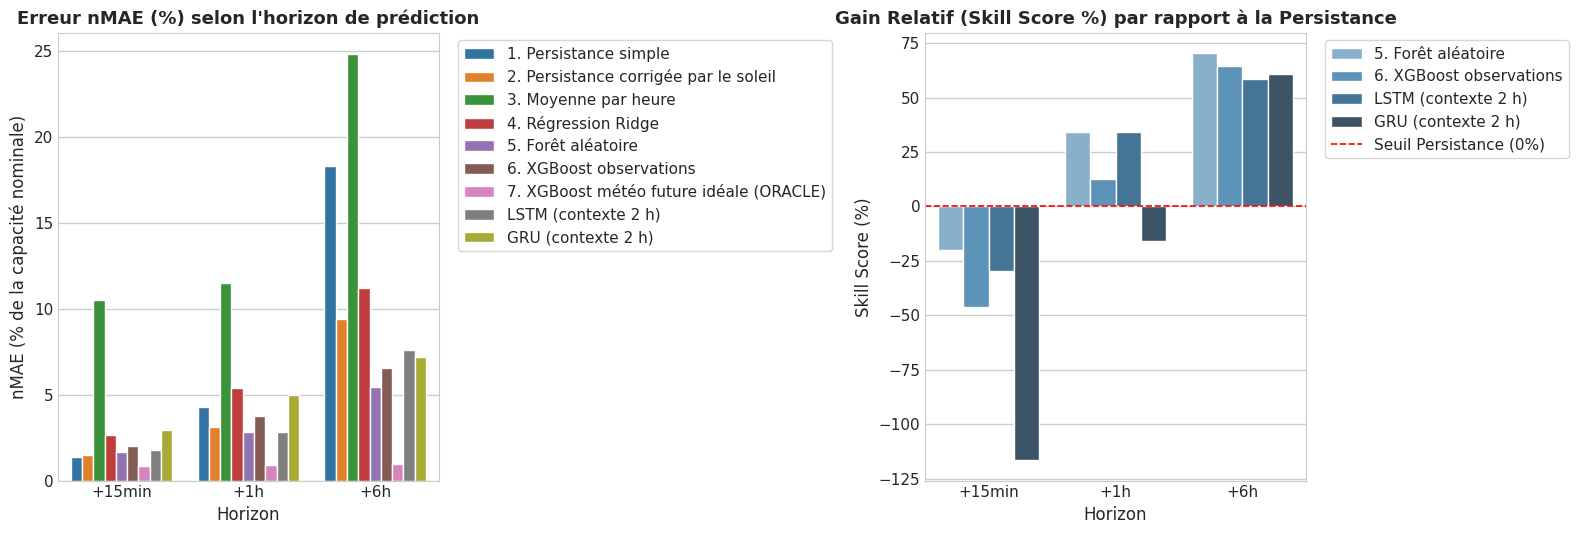

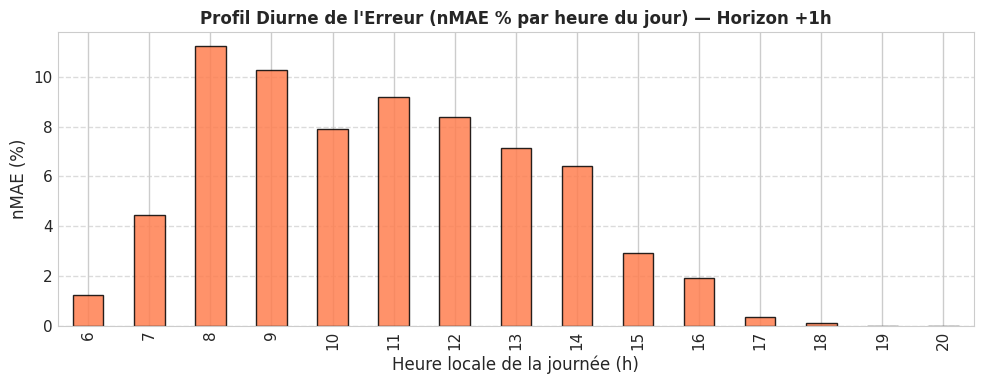

In [137]:
# Consolidation de tous les modèles dans un tableau comparatif maître
df_master_results = pd.concat([df_results_ml, df_results_dl], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Graphique 1 : nMAE (%) par horizon et modèle
palette_colors = sns.color_palette("tab10", df_master_results['Modèle'].nunique())
sns.barplot(data=df_master_results, x='Horizon', y='nMAE(%)', hue='Modèle', ax=axes[0], palette=palette_colors)
axes[0].set_title("Erreur nMAE (%) selon l'horizon de prédiction", fontsize=13, fontweight='bold')
axes[0].set_ylabel("nMAE (% de la capacité nominale)")
axes[0].legend(bbox_to_anchor=(1.03, 1), loc='upper left', frameon=True)

# Graphique 2 : Skill Score (%) par rapport à la persistance naïve
df_ia_only = df_master_results[df_master_results.Famille.isin(['ML-Obs', 'ML-NWP', 'DeepLearning'])]
sns.barplot(data=df_ia_only, x='Horizon', y='Skill(%)', hue='Modèle', ax=axes[1], palette="Blues_d")
axes[1].set_title("Gain Relatif (Skill Score %) par rapport à la Persistance", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Skill Score (%)")
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.2, label='Seuil Persistance (0%)')
axes[1].legend(bbox_to_anchor=(1.03, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

# --- Analyse du profil diurne de l'erreur sur l'horizon +1h ---
df_h1 = generate_lags_and_horizon_targets(df_a, horizon_steps=4)
split_diag = split_and_scale_leakage_free(df_h1, feature_cols=FEATURES_FULL_OBS)
Xte_diag, yte_diag, _ = split_diag['test']
df_te_diag = split_diag['dfs'][2].copy()

xgb_diag = XGBRegressor(n_estimators=250, max_depth=6, learning_rate=0.03, random_state=DEFAULT_SEED)
xgb_diag.fit(split_diag['train'][0], split_diag['train'][1])
df_te_diag['pred_xgb'] = np.clip(xgb_diag.predict(Xte_diag), 0.0, 1.0)
df_te_diag['error_abs'] = np.abs(df_te_diag['target'] - df_te_diag['pred_xgb'])
df_te_diag['hour'] = df_te_diag['timestamp'].dt.hour

diurnal_error = df_te_diag[df_te_diag.hour.between(6, 20)].groupby('hour')['error_abs'].mean() * 100.0

plt.figure(figsize=(10, 4))
diurnal_error.plot(kind='bar', color='coral', edgecolor='black', alpha=0.85)
plt.title("Profil Diurne de l'Erreur (nMAE % par heure du jour) — Horizon +1h", fontsize=12, fontweight='bold')
plt.xlabel("Heure locale de la journée (h)")
plt.ylabel("nMAE (%)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Section 10 : Retirer des groupes de variables pour les comparer

Cette section entraîne plusieurs versions du même modèle avec des groupes de variables différents.

Les versions ajoutent progressivement :

1. les retards de production ;
2. l'heure, le jour et la position du soleil ;
3. la température passée ;
4. l'irradiance passée ;
5. les variations rapides et les autres variables météo.

Le tableau final indique le nombre de variables, l'erreur et le Skill de chaque version. Cela permet de voir quelles informations sont réellement utilisées par le modèle.

>> Exécution de l'étude d'ablation progressive sur l'horizon +1h...
   ✓ 1. Lags Seuls                : nMAE = 3.90%, Skill = 25.56%
   ✓ 2. Lags + Solaire/Temps      : nMAE = 3.85%, Skill = 26.47%
   ✓ 3. Lags + Temps + Temp       : nMAE = 3.17%, Skill = 39.09%
   ✓ 4. Lags + Temps + Temp + GHI : nMAE = 3.44%, Skill = 33.94%
   ✓ 5. Complet (+ Ramp & Deltas) : nMAE = 3.51%, Skill = 32.77%


,Configuration,Nombre de Features,nMAE(%),RMSE,R2,Skill(%)
0,1. Lags Seuls,4,3.897,0.084,0.837,25.556
1,2. Lags + Solaire/Temps,10,3.849,0.075,0.872,26.470
2,3. Lags + Temps + Temp,11,3.172,0.073,0.876,39.089
3,4. Lags + Temps + Temp + GHI,12,3.440,0.075,0.870,33.942
4,5. Complet (+ Ramp & Deltas),18,3.511,0.074,0.875,32.766


/tmp/ipykernel_596/526830177.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_ablation['Configuration'], rotation=20, ha='right')


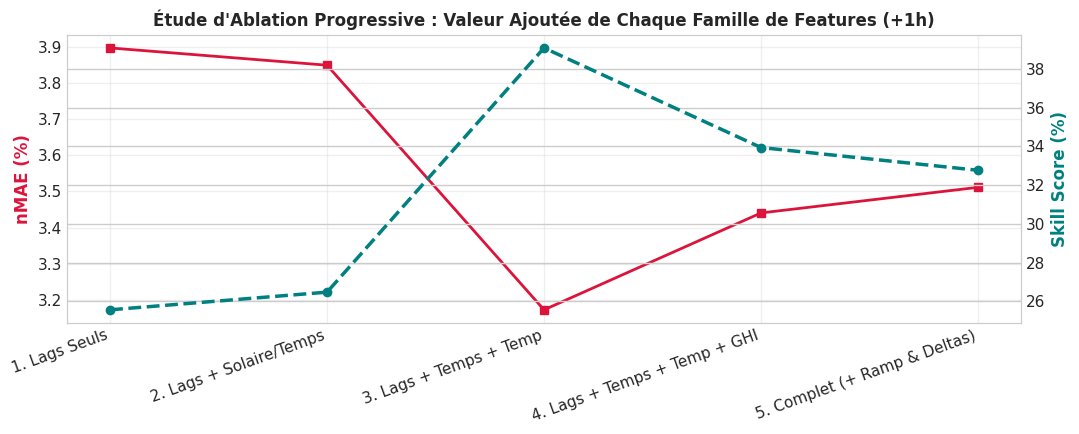

In [138]:
ablation_palette = {
    "1. Lags Seuls": ['lag1', 'lag2', 'lag4', 'roll_mean_1h'],
    "2. Lags + Solaire/Temps": ['lag1', 'lag2', 'lag4', 'roll_mean_1h'] + FEATURES_TIME,
    "3. Lags + Temps + Temp": ['lag1', 'lag2', 'lag4', 'roll_mean_1h'] + FEATURES_TIME + ['lag1_temp'],
    "4. Lags + Temps + Temp + GHI": ['lag1', 'lag2', 'lag4', 'roll_mean_1h'] + FEATURES_TIME + ['lag1_temp', 'lag1_ghi'],
    "5. Complet (+ Ramp & Deltas)": FEATURES_FULL_OBS
}

ablation_metrics = []
df_a_h1 = generate_lags_and_horizon_targets(df_a, horizon_steps=4)  # Horizon +1h

print(">> Exécution de l'étude d'ablation progressive sur l'horizon +1h...")
for config_name, feature_subset in ablation_palette.items():
    sp = split_and_scale_leakage_free(df_a_h1, feature_cols=feature_subset)
    Xtr, ytr, _ = sp['train']
    Xval, yval, _ = sp['val']
    Xte, yte, _ = sp['test']

    m_xgb = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.04, random_state=DEFAULT_SEED, early_stopping_rounds=10)
    m_xgb.fit(Xtr, ytr, eval_set=[(Xval, yval)], verbose=False)

    p = m_xgb.predict(Xte)
    res = calculate_comprehensive_metrics(yte, p, sp['dfs'][2]['lag1'].values)
    ablation_metrics.append({
        'Configuration': config_name,
        'Nombre de Features': len(feature_subset),
        **res
    })
    print(f"   ✓ {config_name:<28} : nMAE = {res['nMAE(%)']:.2f}%, Skill = {res['Skill(%)']:.2f}%")

df_ablation = pd.DataFrame(ablation_metrics)
display(df_ablation[['Configuration', 'Nombre de Features', 'nMAE(%)', 'RMSE', 'R2', 'Skill(%)']].round(3))

# Visualisation du gain incrémental
fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax2 = ax1.twinx()

ax1.plot(df_ablation['Configuration'], df_ablation['nMAE(%)'], color='crimson', marker='s', linewidth=2, label='nMAE (%) - À minimiser')
ax2.plot(df_ablation['Configuration'], df_ablation['Skill(%)'], color='teal', marker='o', linewidth=2.5, linestyle='--', label='Skill Score (%) - À maximiser')

ax1.set_ylabel("nMAE (%)", color='crimson', fontweight='bold')
ax2.set_ylabel("Skill Score (%)", color='teal', fontweight='bold')
ax1.set_xticklabels(df_ablation['Configuration'], rotation=20, ha='right')
ax1.set_title("Étude d'Ablation Progressive : Valeur Ajoutée de Chaque Famille de Features (+1h)", fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Section 11 : Comprendre les variables avec SHAP

SHAP mesure l'influence de chaque variable sur une prédiction.

Pour chaque ligne, une valeur SHAP positive pousse la prédiction vers le haut. Une valeur SHAP négative pousse la prédiction vers le bas. La valeur absolue indique l'importance de l'influence.

Le graphique en barres classe les variables selon leur influence moyenne. Le graphique beeswarm montre à la fois l'importance et le sens de l'influence.

Cette information aide à comprendre quelles mesures sont les plus utiles au modèle.

>> Calcul des valeurs d'attribution TreeSHAP...


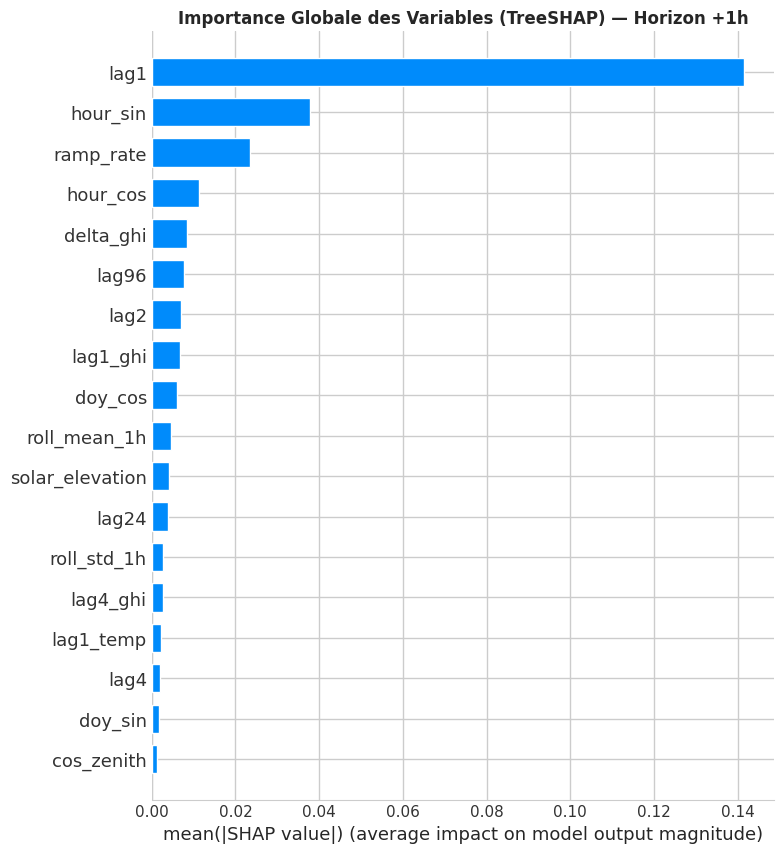

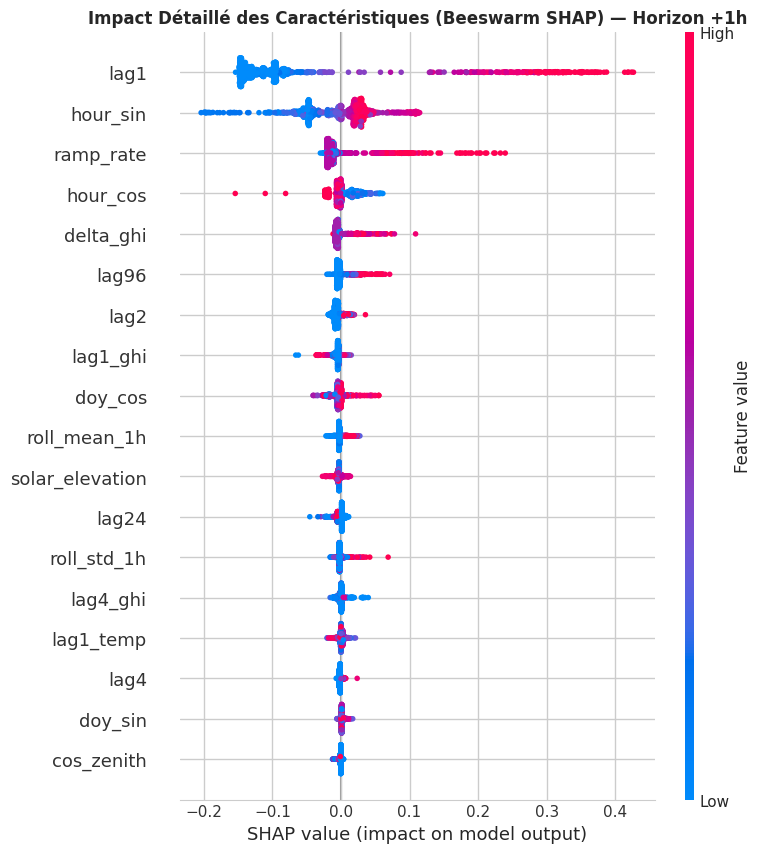

In [139]:
# Entraînement d'un modèle XGBoost dédié à l'interprétation SHAP (+1h)
split_shap = split_and_scale_leakage_free(df_a_h1, feature_cols=FEATURES_FULL_OBS)
Xtr_sh, ytr_sh, _ = split_shap['train']
Xval_sh, yval_sh, _ = split_shap['val']
Xte_sh, yte_sh, _ = split_shap['test']

xgb_shap = XGBRegressor(n_estimators=250, max_depth=6, learning_rate=0.03, random_state=DEFAULT_SEED)
xgb_shap.fit(Xtr_sh, ytr_sh, eval_set=[(Xval_sh, yval_sh)], verbose=False)

# Échantillon de test représentatif pour optimiser le temps de calcul
sample_size = min(1200, len(Xte_sh))
X_sample = Xte_sh.sample(sample_size, random_state=DEFAULT_SEED)

print(">> Calcul des valeurs d'attribution TreeSHAP...")
explainer = shap.TreeExplainer(xgb_shap)
shap_values = explainer.shap_values(X_sample)

# 1. Bar Plot : Importance globale absolue
plt.figure(figsize=(10, 5))
plt.title("Importance Globale des Variables (TreeSHAP) — Horizon +1h", fontsize=12, fontweight='bold')
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=True)

# 2. Beeswarm Plot : Directionnalité et distribution des impacts
plt.figure(figsize=(11, 6.5))
plt.title("Impact Détaillé des Caractéristiques (Beeswarm SHAP) — Horizon +1h", fontsize=12, fontweight='bold')
shap.summary_plot(shap_values, X_sample, show=True)


## Section 12 : Comparer les sites et observer les onduleurs

Cette section utilise le modèle appris sur le site A et le teste sur les autres sites disponibles.

Le test est réalisé sur toutes les lignes valides de chaque site cible. Le tableau indique le nombre de lignes testées et les mesures d'erreur.

Pour BR-PVGen, les fichiers `PS_001.csv` à `PS_051.csv` représentent 51 centrales. Les valeurs électriques sont agrégées par centrale et par date. La cellule d'analyse détaillée utilise les coordonnées solaires uniquement lorsqu'elles sont documentées dans les données.

La deuxième partie étudie le rendement d'un onduleur :

$$\eta = \frac{P_{AC}}{P_{DC}}$$

Un rendement proche de 1 signifie que la conversion entre la puissance continue et la puissance alternative est efficace. Les graphiques montrent le rendement selon la puissance DC et selon la température interne.

Matrice de Generalisation Multi-Sites (Horizon +1h, cible entiere) :


,Source,Cible,N_test,nMAE(%),RMSE,R2,Skill(%)
0,A (Italie),A (Italie),NaN,3.206,0.077,0.867,38.804
1,A (Italie),B (Australie),60012.0,6.105,0.114,0.751,12.884
2,A (Italie),C (Inde),3058.0,5.519,0.102,0.883,45.962



>> Analyse de la courbe de rendement des onduleurs reels (BR-PVGen)...


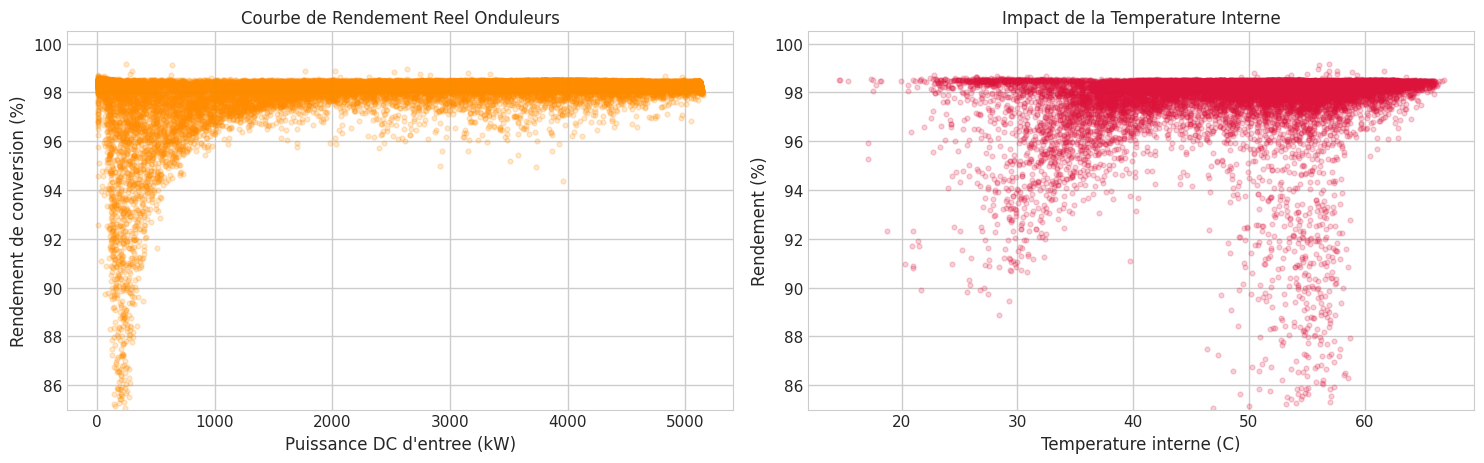

In [140]:
# =====================================================================
# 12.1 Matrice de Transfert Geographique Inter-Sites
# =====================================================================
transfer_records = []
eval_horizon = 4  # +1h sur des donnees a 15 minutes

df_a_h = generate_lags_and_horizon_targets(datasets_engineered['A'], horizon_steps=eval_horizon)
sp_a = split_and_scale_leakage_free(df_a_h, feature_cols=FEATURES_TIME_LAGS)
model_trans = XGBRegressor(n_estimators=250, max_depth=6, learning_rate=0.03, random_state=DEFAULT_SEED)
model_trans.fit(sp_a['train'][0], sp_a['train'][1])
p_a = model_trans.predict(sp_a['test'][0])
transfer_records.append({
    'Source': 'A (Italie)', 'Cible': 'A (Italie)',
    **calculate_comprehensive_metrics(sp_a['test'][1], p_a, sp_a['dfs'][2]['lag1'].values)
})

# Evaluation sur l'integralite de chaque site cible, protocole fixe avant l'experience.
for code_c, name_c in [('B', 'B (Australie)'), ('C', 'C (Inde)'), ('D', 'D (Bresil - BR-PVGen)')]:
    if code_c not in datasets_engineered:
        continue
    df_c_h = generate_lags_and_horizon_targets(datasets_engineered[code_c], horizon_steps=eval_horizon)
    df_test_c = df_c_h.dropna(subset=FEATURES_TIME_LAGS + ['target']).reset_index(drop=True)
    preds_c = model_trans.predict(df_test_c[FEATURES_TIME_LAGS])
    transfer_records.append({
        'Source': 'A (Italie)', 'Cible': name_c,
        'N_test': len(df_test_c),
        **calculate_comprehensive_metrics(df_test_c['target'], preds_c, df_test_c['lag1'].values)
    })

df_transfer_matrix = pd.DataFrame(transfer_records)
print("Matrice de Generalisation Multi-Sites (Horizon +1h, cible entiere) :")
display(df_transfer_matrix[['Source', 'Cible', 'N_test', 'nMAE(%)', 'RMSE', 'R2', 'Skill(%)']].round(3))


# =====================================================================
# 12.2 Etude Physique des Onduleurs BR-PVGen
# =====================================================================
if 'D' in raw_datasets:
    print("\n>> Analyse de la courbe de rendement des onduleurs reels (BR-PVGen)...")
    df_d = raw_datasets['D']
    valid_inverters = df_d.dropna(subset=['inverter_efficiency', 'power_dc_kw', 'inverter_temp_c'])
    valid_inverters = valid_inverters[(valid_inverters.power_dc_kw > 5.0) & (valid_inverters.inverter_efficiency.between(0.85, 1.0))]
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
    axes[0].scatter(valid_inverters['power_dc_kw'], valid_inverters['inverter_efficiency'] * 100.0, alpha=0.2, color='darkorange', s=12)
    axes[0].set_title("Courbe de Rendement Reel Onduleurs")
    axes[0].set_xlabel("Puissance DC d'entree (kW)")
    axes[0].set_ylabel("Rendement de conversion (%)")
    axes[0].set_ylim(85, 100.5)
    axes[1].scatter(valid_inverters['inverter_temp_c'], valid_inverters['inverter_efficiency'] * 100.0, alpha=0.2, color='crimson', s=12)
    axes[1].set_title("Impact de la Temperature Interne")
    axes[1].set_xlabel("Temperature interne (C)")
    axes[1].set_ylabel("Rendement (%)")
    axes[1].set_ylim(85, 100.5)
    plt.tight_layout()
    plt.show()


In [141]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


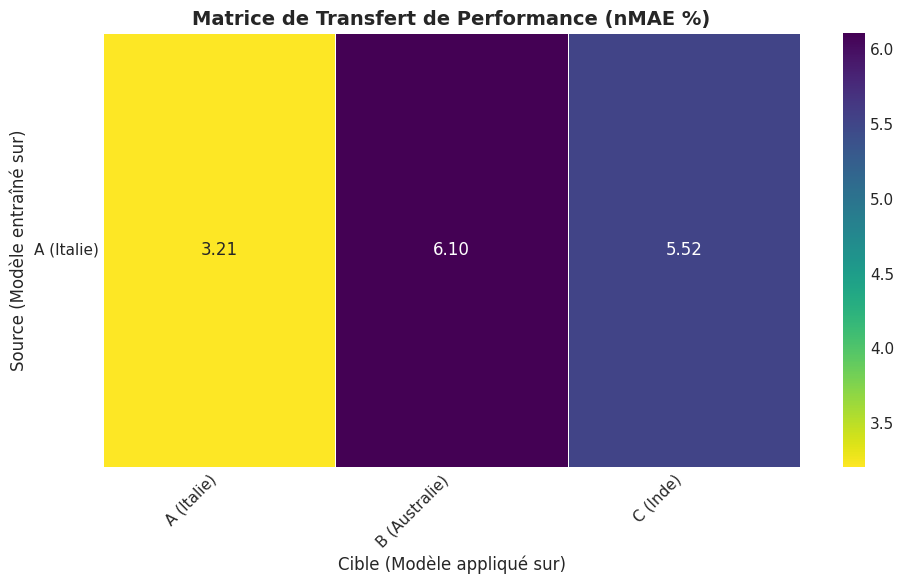

In [142]:
transfer_pivot = df_transfer_matrix.pivot_table(index='Source', columns='Cible', values='nMAE(%)')

plt.figure(figsize=(10, 6))
sns.heatmap(transfer_pivot, annot=True, cmap='viridis_r', fmt=".2f", linewidths=.5)
plt.title('Matrice de Transfert de Performance (nMAE %)', fontsize=14, fontweight='bold')
plt.xlabel('Cible (Modèle appliqué sur)', fontsize=12)
plt.ylabel('Source (Modèle entraîné sur)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [143]:
def assign_performance_tier(skill_score):
    if skill_score >= 75.0:
        return 'Excellent'
    elif skill_score >= 50.0:
        return 'Good'
    elif skill_score >= 25.0:
        return 'Moderate'
    else:
        return 'Poor'

# Apply the function to create the new column
df_transfer_matrix['Performance Tier'] = df_transfer_matrix['Skill(%)'].apply(assign_performance_tier)

print("Matrice de Généralisation Multi-Sites avec Performance Tier :")
display(df_transfer_matrix[['Source', 'Cible', 'nMAE(%)', 'Skill(%)', 'Performance Tier']].round(3))

Matrice de Généralisation Multi-Sites avec Performance Tier :


,Source,Cible,nMAE(%),Skill(%),Performance Tier
0,A (Italie),A (Italie),3.206,38.804,Moderate
1,A (Italie),B (Australie),6.105,12.884,Poor
2,A (Italie),C (Inde),5.519,45.962,Moderate


### Analyse de la performance de généralisation

Analysons les performances de généralisation du modèle entraîné sur le site A (Italie) vers les autres sites, en excluant les auto-prédictions.

In [144]:
df_generalization_performance = df_transfer_matrix[df_transfer_matrix['Source'] != df_transfer_matrix['Cible']].copy()

df_generalization_performance = df_generalization_performance.sort_values(
    by=['Performance Tier', 'Skill(%)'],
    ascending=[True, False]
)

print("Analyse de la performance de généralisation (modèle A vers d'autres sites) :")
display(df_generalization_performance[['Source', 'Cible', 'nMAE(%)', 'Skill(%)', 'Performance Tier']].round(3))

Analyse de la performance de généralisation (modèle A vers d'autres sites) :


,Source,Cible,nMAE(%),Skill(%),Performance Tier
2,A (Italie),C (Inde),5.519,45.962,Moderate
1,A (Italie),B (Australie),6.105,12.884,Poor


### Visualisation des Performances de Généralisation

Cette section compare visuellement la performance du modèle entraîné sur le site A (Italie) lorsqu'il est appliqué à d'autres sites. Nous allons observer deux indicateurs clés : le nMAE (erreur moyenne normalisée) et le Skill Score (gain par rapport à la persistance).

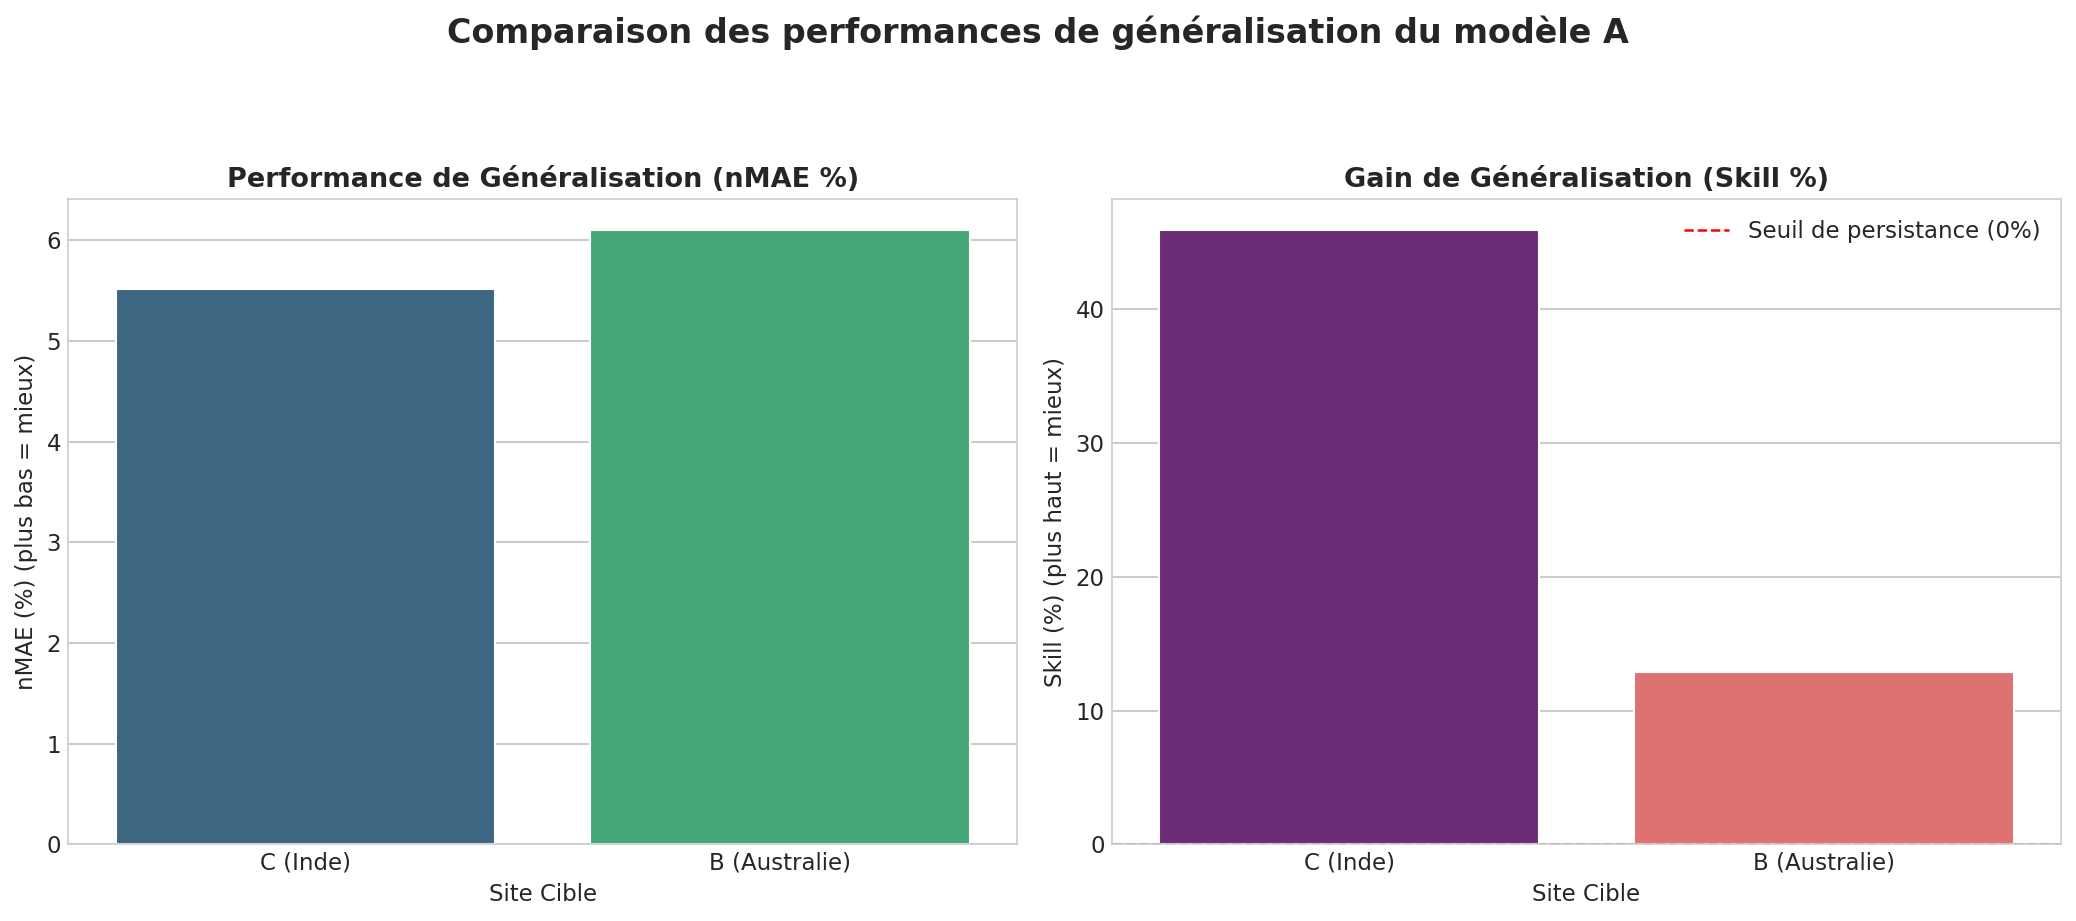

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Assurez-vous que le dossier de publication existe
output_dir = 'figures_publication'
os.makedirs(output_dir, exist_ok=True)

# Création de deux sous-graphiques pour comparer nMAE et Skill
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150)

# Graphique nMAE (%)
sns.barplot(x='Cible', y='nMAE(%)', data=df_generalization_performance, ax=axes[0], palette='viridis')
axes[0].set_title('Performance de Généralisation (nMAE %)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Site Cible', fontsize=11)
axes[0].set_ylabel('nMAE (%) (plus bas = mieux)', fontsize=11)
axes[0].tick_params(axis='x', rotation=0) # Garde les étiquettes droites

# Graphique Skill Score (%)
sns.barplot(x='Cible', y='Skill(%)', data=df_generalization_performance, ax=axes[1], palette='magma')
axes[1].set_title('Gain de Généralisation (Skill %)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Site Cible', fontsize=11)
axes[1].set_ylabel('Skill (%) (plus haut = mieux)', fontsize=11)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.2, label='Seuil de persistance (0%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()

plt.suptitle('Comparaison des performances de généralisation du modèle A', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Ajuste le layout pour le titre global
plt.savefig(os.path.join(output_dir, '05_generalization_performance_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

### Sauvegarde des graphiques supplémentaires pour la publication

Nous allons maintenant sauvegarder les graphiques de l'étude d'ablation, des valeurs SHAP et de l'étude des onduleurs BR-PVGen, qui n'ont été affichés qu'à l'écran jusqu'à présent.

/tmp/ipykernel_596/2605707602.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_ablation['Configuration'], rotation=20, ha='right')


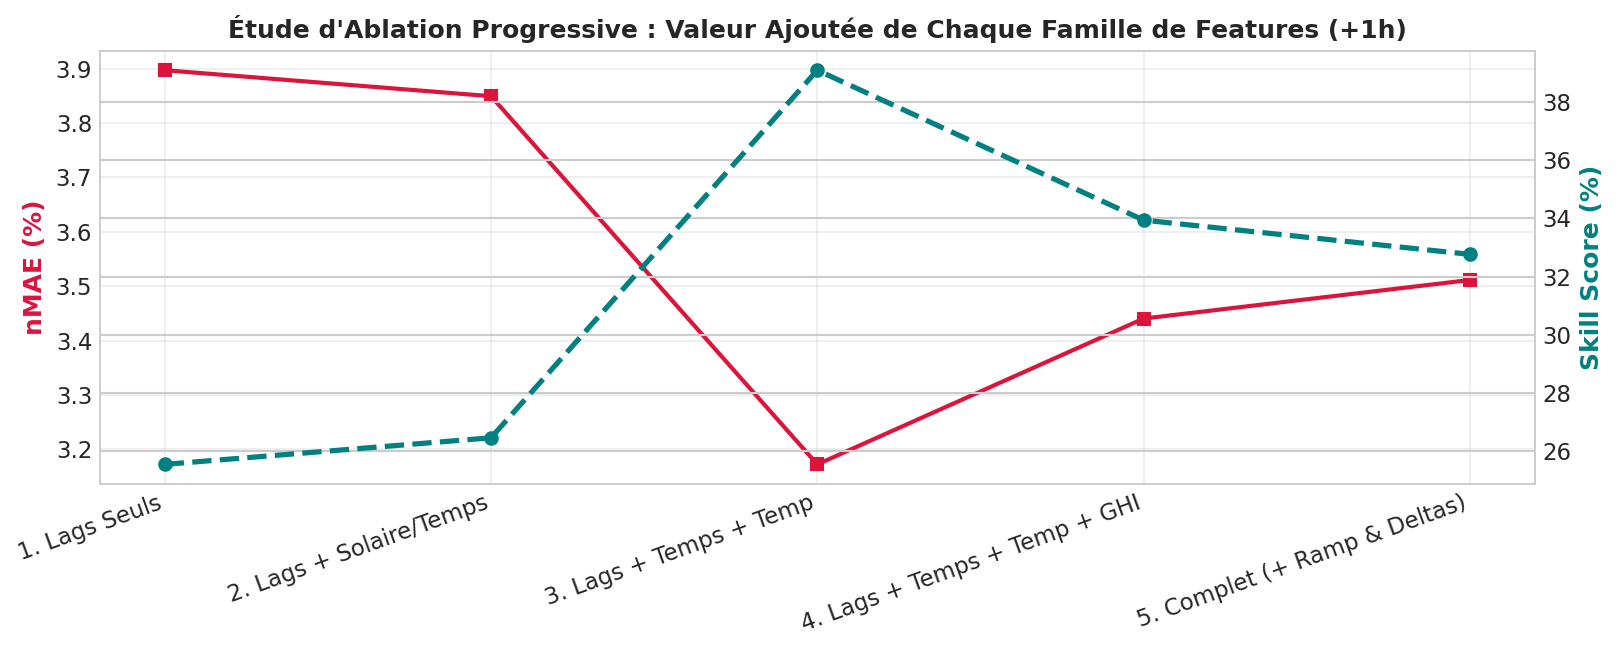

In [146]:
# Section 10 : Sauvegarde du graphique de l'étude d'ablation

output_dir = 'figures_publication'
os.makedirs(output_dir, exist_ok=True)

# Recrée le graphique de l'étude d'ablation
fig, ax1 = plt.subplots(figsize=(11, 4.5), dpi=150)
ax2 = ax1.twinx()

ax1.plot(df_ablation['Configuration'], df_ablation['nMAE(%)'], color='crimson', marker='s', linewidth=2, label='nMAE (%) - À minimiser')
ax2.plot(df_ablation['Configuration'], df_ablation['Skill(%)'], color='teal', marker='o', linewidth=2.5, linestyle='--', label='Skill Score (%) - À maximiser')

ax1.set_ylabel("nMAE (%)", color='crimson', fontweight='bold')
ax2.set_ylabel("Skill Score (%)", color='teal', fontweight='bold')
ax1.set_xticklabels(df_ablation['Configuration'], rotation=20, ha='right')
ax1.set_title("Étude d'Ablation Progressive : Valeur Ajoutée de Chaque Famille de Features (+1h)", fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '06_ablation_study_plot.png'), dpi=300, bbox_inches='tight')
plt.show()

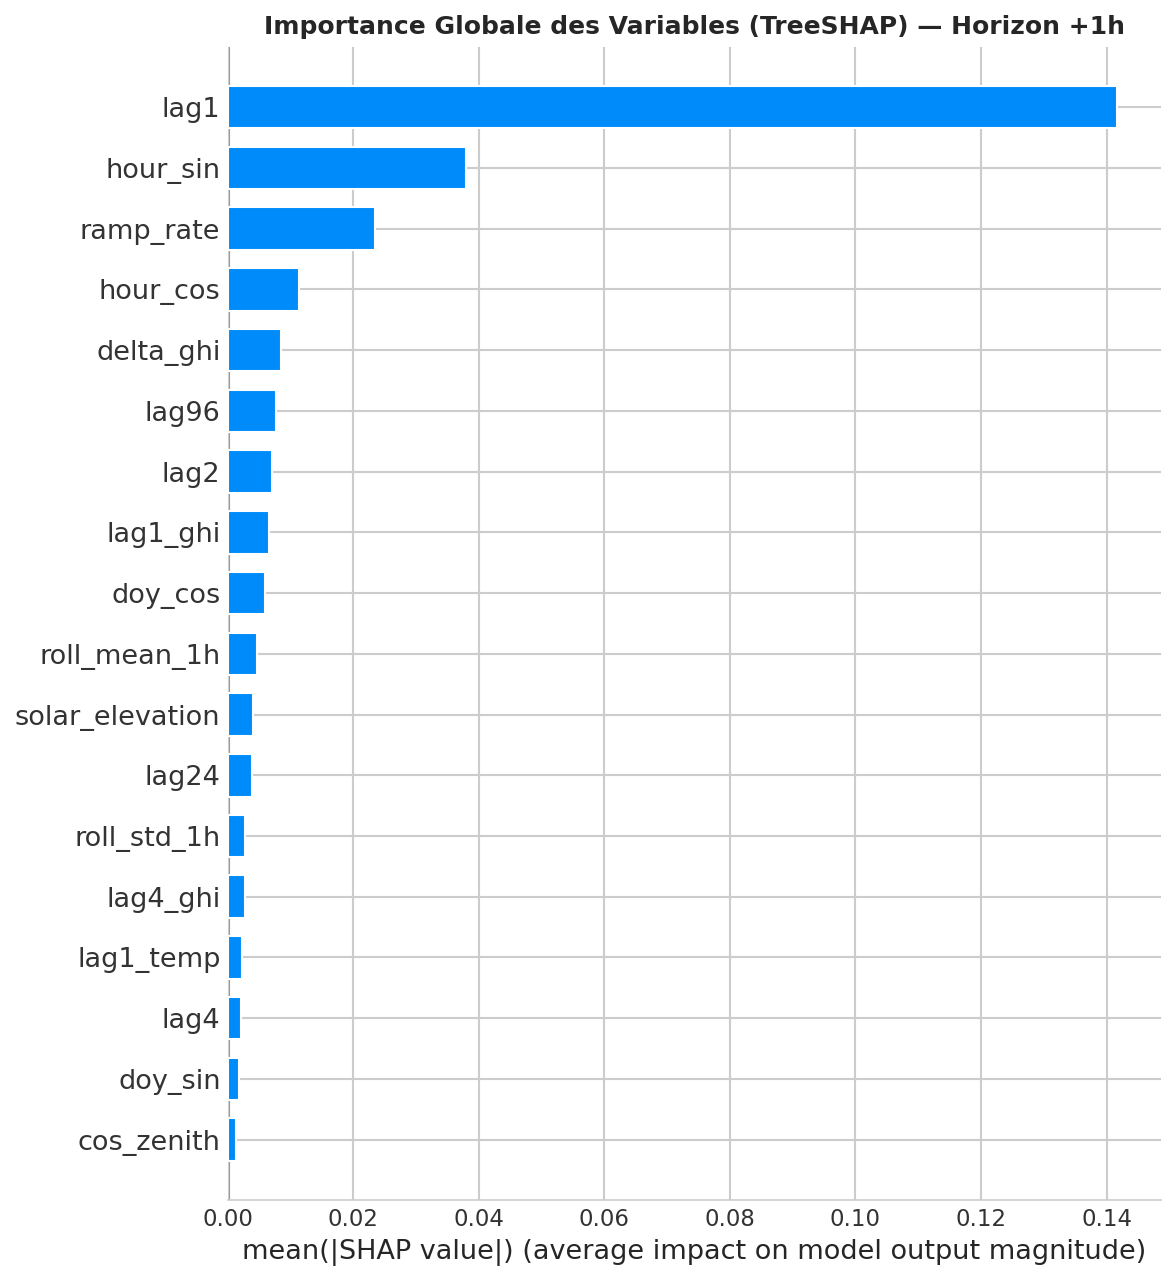

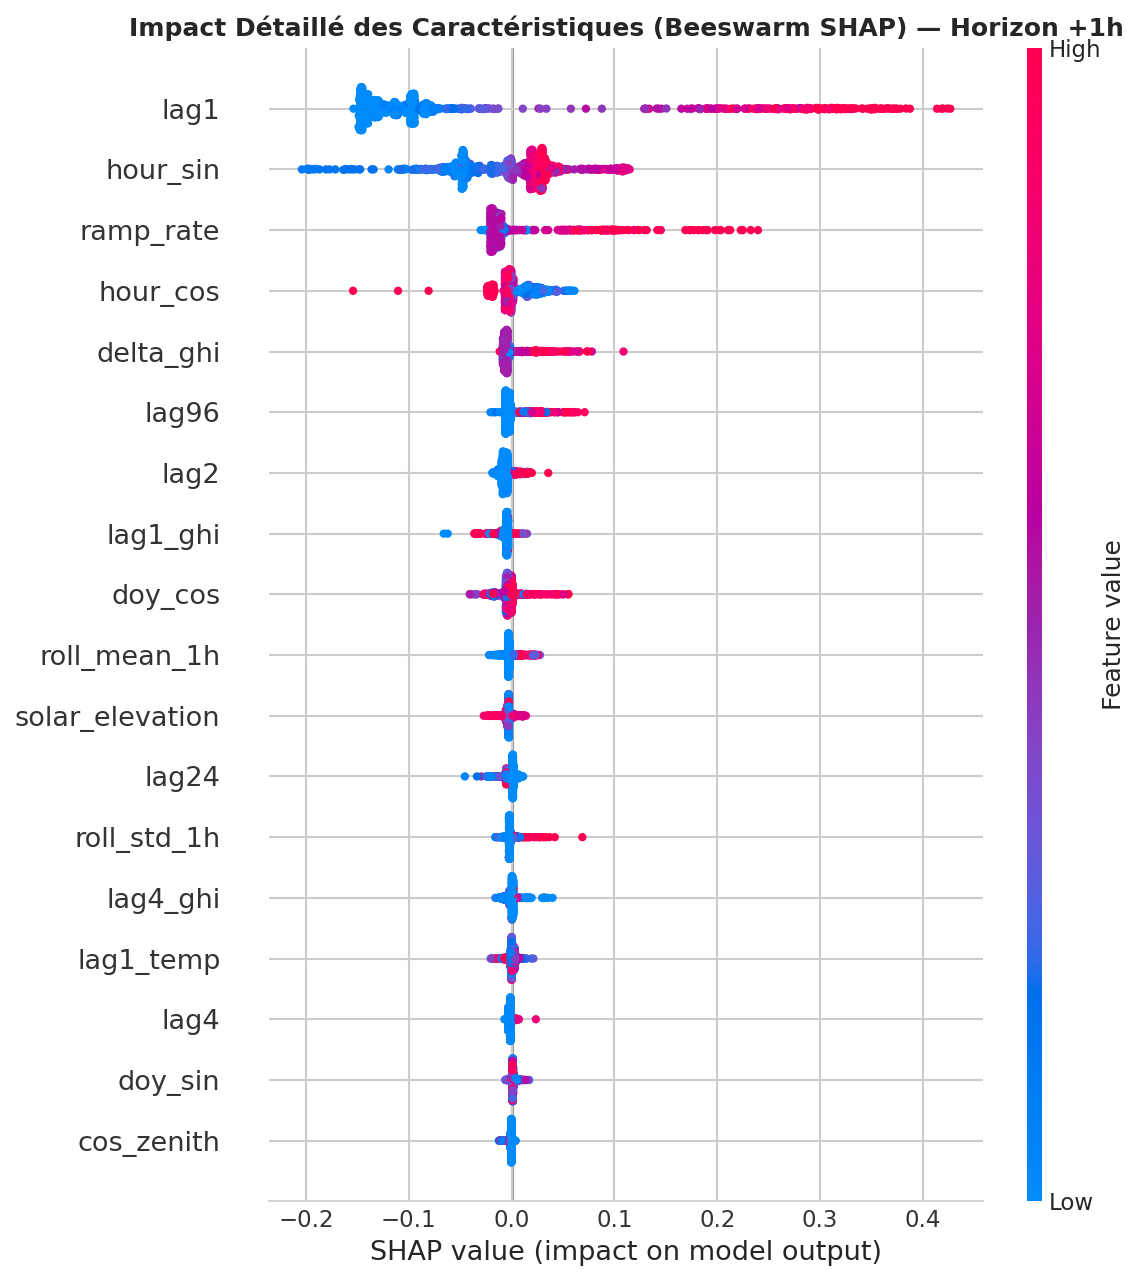

In [147]:
# Section 11 : Sauvegarde des graphiques SHAP

output_dir = 'figures_publication'
os.makedirs(output_dir, exist_ok=True)

# Recalcul de l'explainer et des valeurs SHAP (si nécessaire)
# Les variables `xgb_shap`, `X_sample`, `explainer`, `shap_values` devraient être disponibles depuis l'exécution précédente.
# Si ce n'est pas le cas, décommentez et exécutez le bloc suivant :
# split_shap = split_and_scale_leakage_free(df_a_h1, feature_cols=FEATURES_FULL_OBS)
# Xtr_sh, ytr_sh, _ = split_shap['train']
# Xval_sh, yval_sh, _ = split_shap['val']
# Xte_sh, yte_sh, _ = split_shap['test']
# xgb_shap = XGBRegressor(n_estimators=250, max_depth=6, learning_rate=0.03, random_state=DEFAULT_SEED)
# xgb_shap.fit(Xtr_sh, ytr_sh, eval_set=[(Xval_sh, yval_sh)], verbose=False)
# sample_size = min(1200, len(Xte_sh))
# X_sample = Xte_sh.sample(sample_size, random_state=DEFAULT_SEED)
# explainer = shap.TreeExplainer(xgb_shap)
# shap_values = explainer.shap_values(X_sample)

# 1. Bar Plot : Importance globale absolue
plt.figure(figsize=(10, 5), dpi=150)
plt.title("Importance Globale des Variables (TreeSHAP) — Horizon +1h", fontsize=12, fontweight='bold')
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False) # show=False pour sauvegarder
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '07_shap_bar_plot.png'), dpi=300, bbox_inches='tight')
plt.show()

# 2. Beeswarm Plot : Directionnalité et distribution des impacts
plt.figure(figsize=(11, 6.5), dpi=150)
plt.title("Impact Détaillé des Caractéristiques (Beeswarm SHAP) — Horizon +1h", fontsize=12, fontweight='bold')
shap.summary_plot(shap_values, X_sample, show=False) # show=False pour sauvegarder
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '08_shap_beeswarm_plot.png'), dpi=300, bbox_inches='tight')
plt.show()

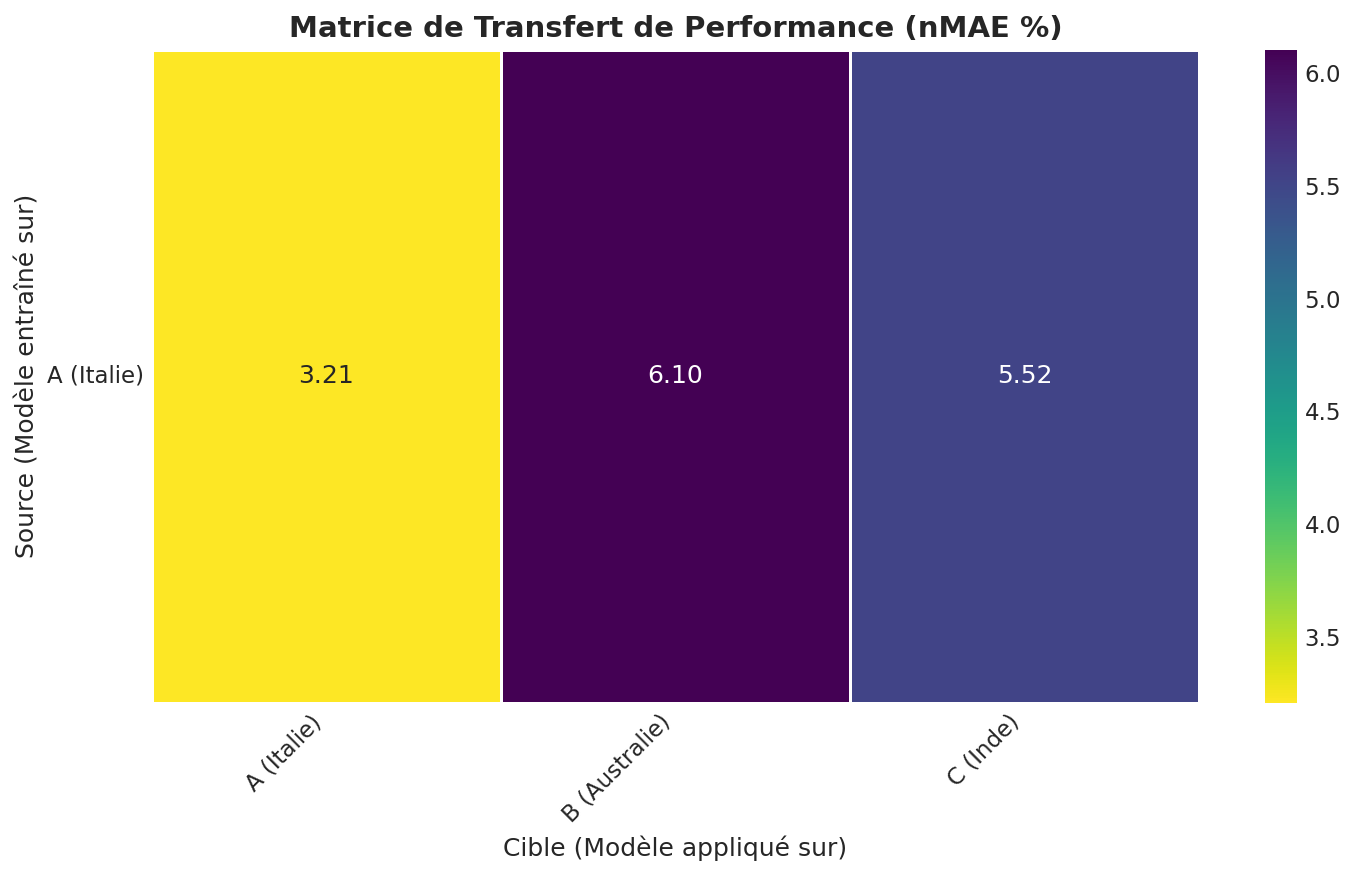

In [148]:
# Section 12 : Sauvegarde de la carte thermique de la matrice de transfert

output_dir = 'figures_publication'
os.makedirs(output_dir, exist_ok=True)

transfer_pivot = df_transfer_matrix.pivot_table(index='Source', columns='Cible', values='nMAE(%)')

plt.figure(figsize=(10, 6), dpi=150)
sns.heatmap(transfer_pivot, annot=True, cmap='viridis_r', fmt=".2f", linewidths=.5)
plt.title('Matrice de Transfert de Performance (nMAE %)', fontsize=14, fontweight='bold')
plt.xlabel('Cible (Modèle appliqué sur)', fontsize=12)
plt.ylabel('Source (Modèle entraîné sur)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '09_transfer_matrix_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

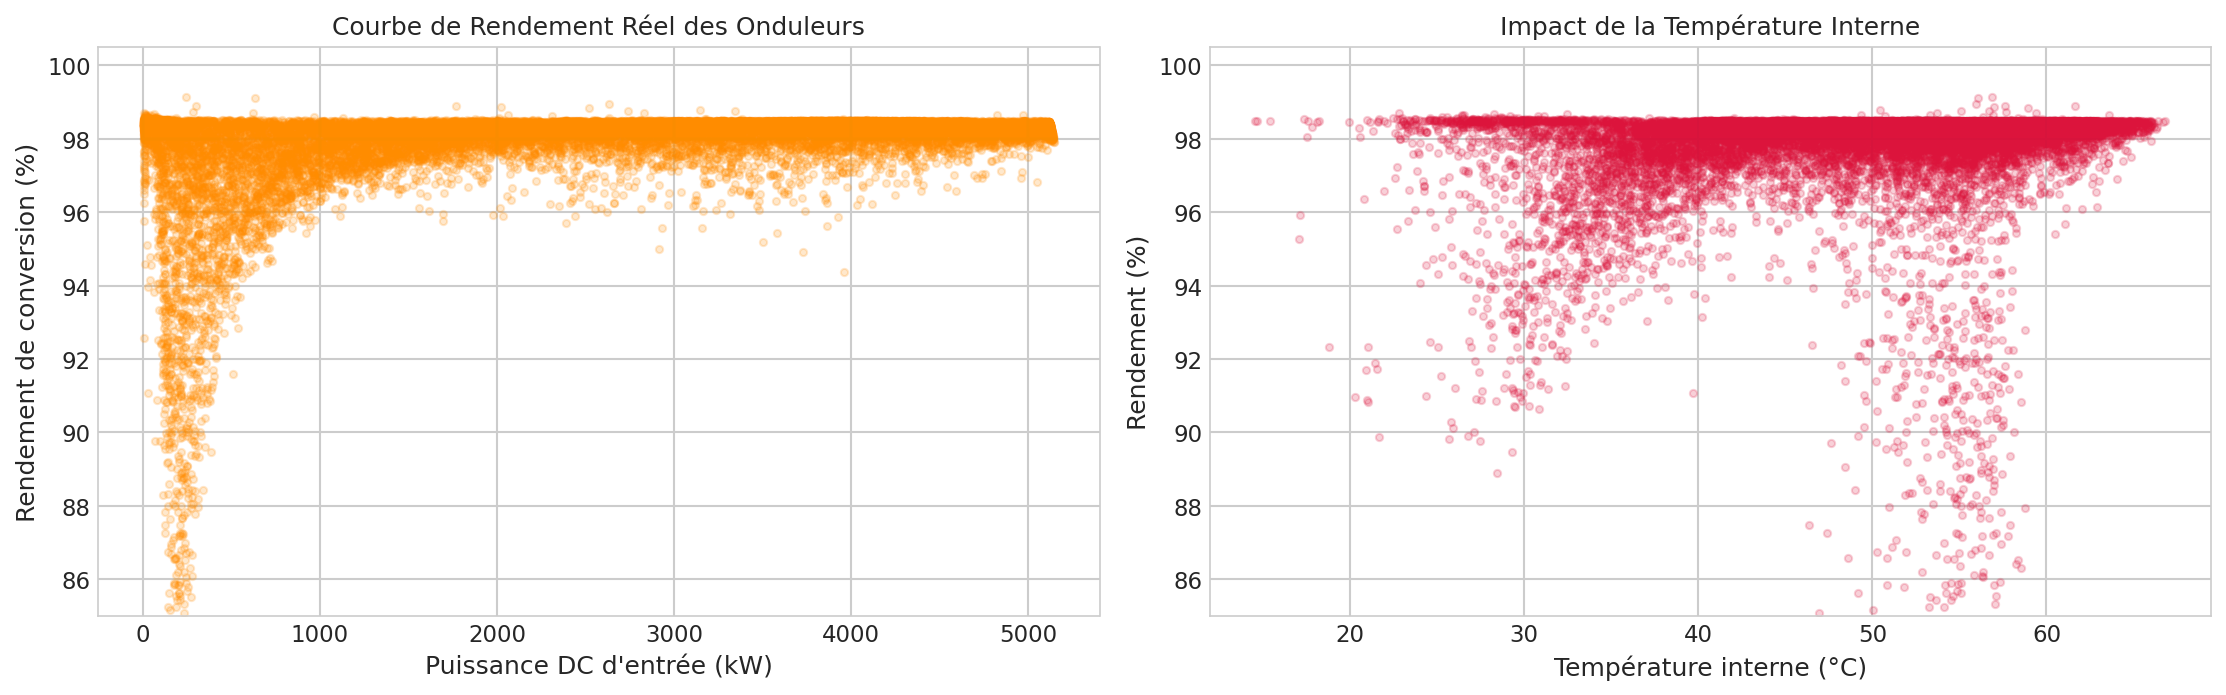

In [149]:
# Section 12 : Sauvegarde des graphiques d'étude des onduleurs BR-PVGen

output_dir = 'figures_publication'
os.makedirs(output_dir, exist_ok=True)

# Les variables `raw_datasets` et `df_d` devraient être disponibles depuis l'exécution précédente.
# Si ce n'est pas le cas, le bloc `if 'D' in raw_datasets:` ne s'exécutera pas.
if 'D' in raw_datasets:
    df_d = raw_datasets['D']
    valid_inverters = df_d.dropna(subset=['inverter_efficiency', 'power_dc_kw', 'inverter_temp_c'])
    valid_inverters = valid_inverters[(valid_inverters.power_dc_kw > 5.0) & (valid_inverters.inverter_efficiency.between(0.85, 1.0))]

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), dpi=150)

    # Graphique 1 : Courbe de Rendement Reel Onduleurs
    axes[0].scatter(valid_inverters['power_dc_kw'], valid_inverters['inverter_efficiency'] * 100.0, alpha=0.2, color='darkorange', s=12)
    axes[0].set_title("Courbe de Rendement Réel des Onduleurs")
    axes[0].set_xlabel("Puissance DC d'entrée (kW)")
    axes[0].set_ylabel("Rendement de conversion (%)")
    axes[0].set_ylim(85, 100.5)

    # Graphique 2 : Impact de la Température Interne
    axes[1].scatter(valid_inverters['inverter_temp_c'], valid_inverters['inverter_efficiency'] * 100.0, alpha=0.2, color='crimson', s=12)
    axes[1].set_title("Impact de la Température Interne")
    axes[1].set_xlabel("Température interne (°C)")
    axes[1].set_ylabel("Rendement (%)")
    axes[1].set_ylim(85, 100.5)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, '10_br_pvgen_inverter_study.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Le Dataset D (BR-PVGen) n'est pas disponible pour l'étude des onduleurs.")

## Section 13 : Résumé des étapes

Le notebook réalise les opérations suivantes :

1. il trouve les fichiers dans le dossier local ou dans Google Drive ;
2. il lit les mesures des quatre sources ;
3. il convertit les puissances dans les bonnes unités ;
4. il vérifie les dates, le pas de 15 minutes et les valeurs manquantes ;
5. il calcule le facteur de charge ;
6. il ajoute les informations sur l'heure, la météo et la position du soleil ;
7. il sépare les données en entraînement, validation et test ;
8. il entraîne plusieurs modèles ;
9. il calcule les erreurs ;
10. il affiche les graphiques et l'influence des variables.

Les tableaux et les graphiques produits par les cellules permettent de suivre chaque étape et de comprendre comment les prédictions sont obtenues.

**Serigne Fallou Faye**

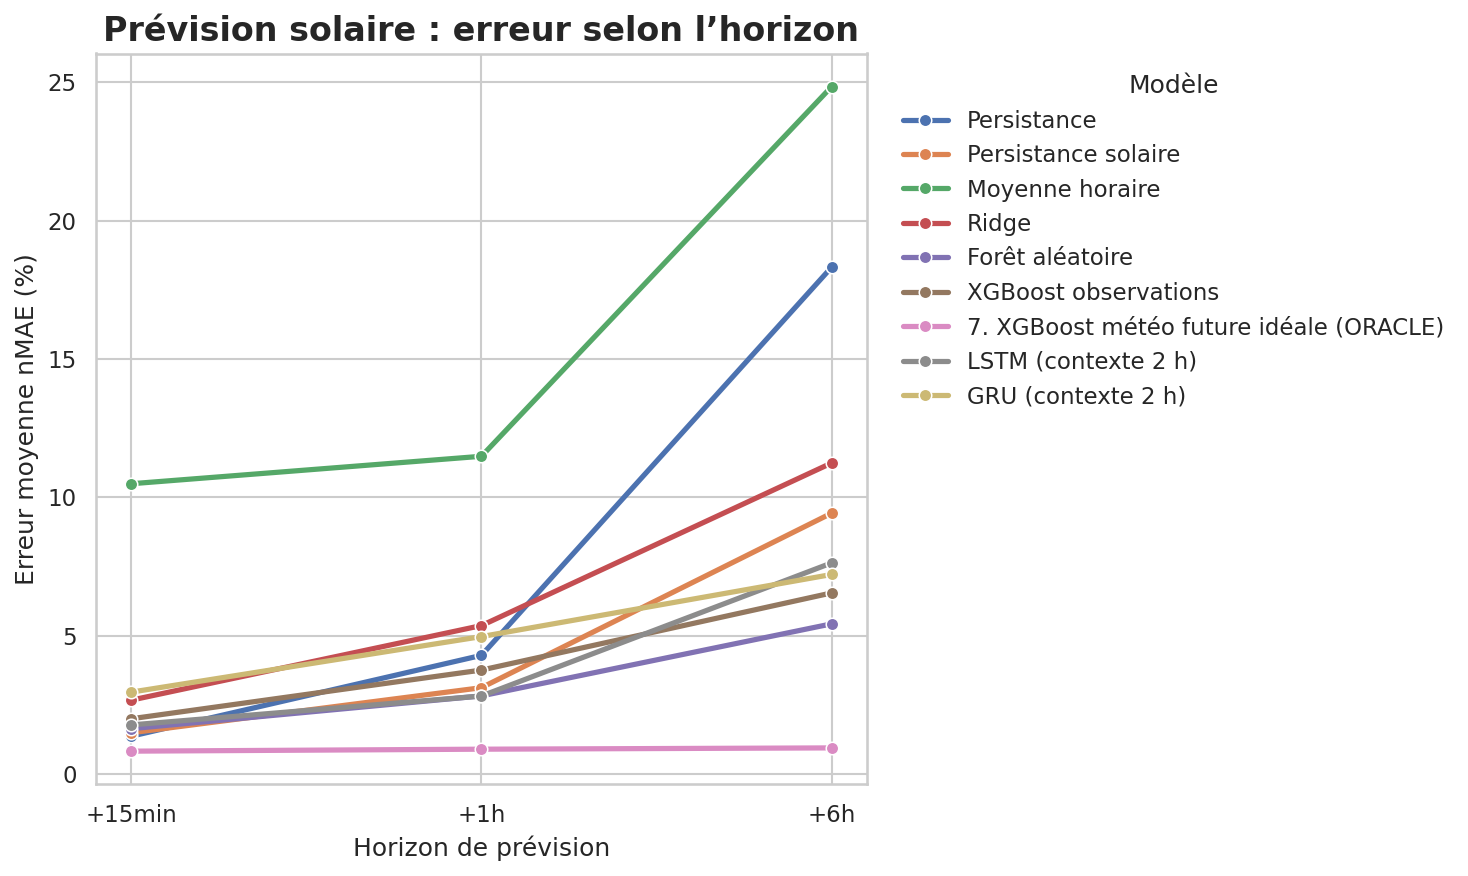

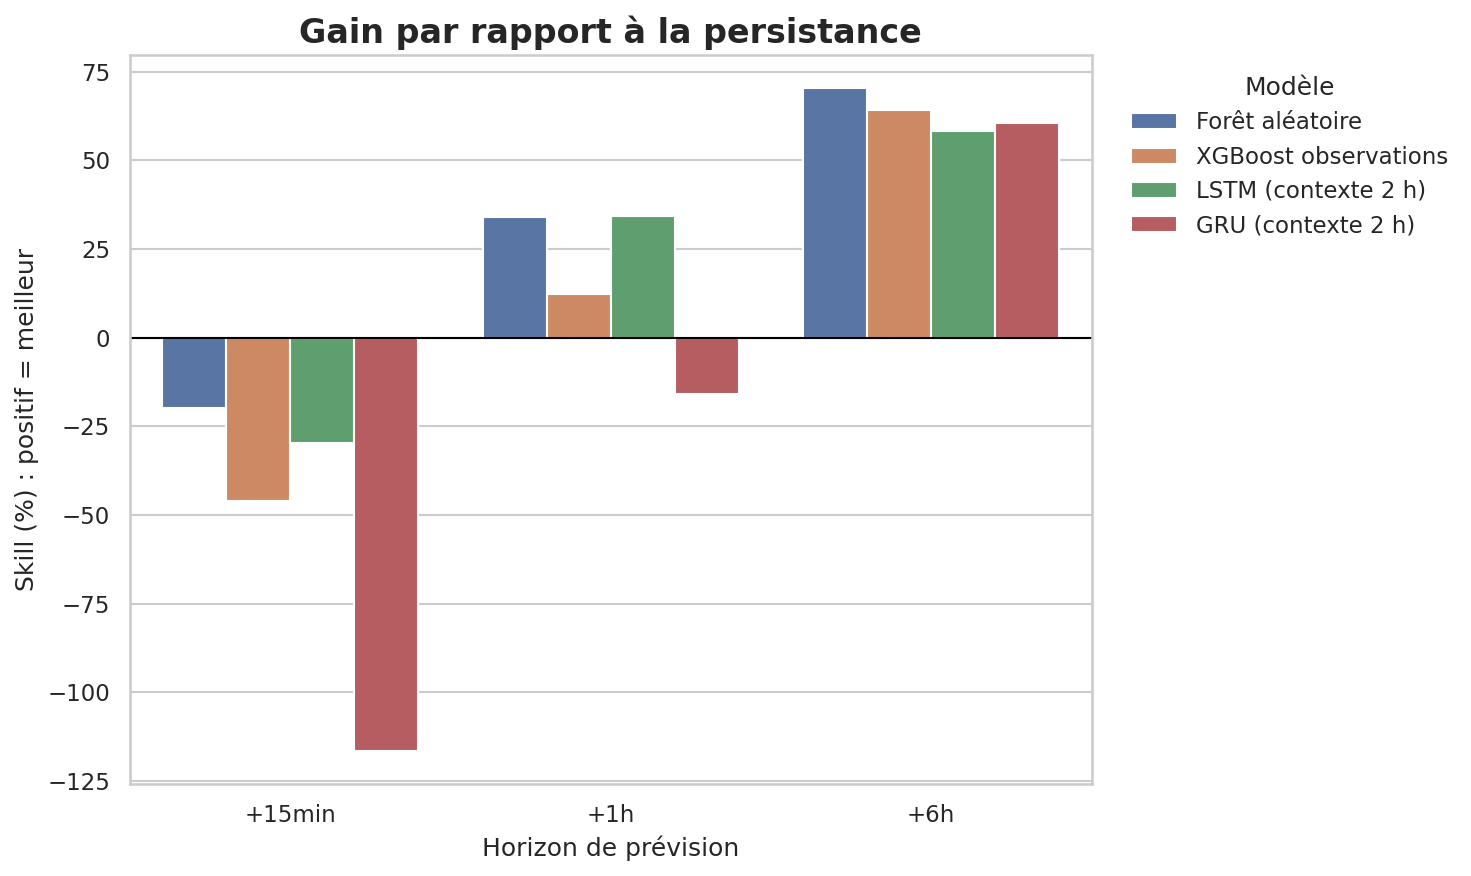

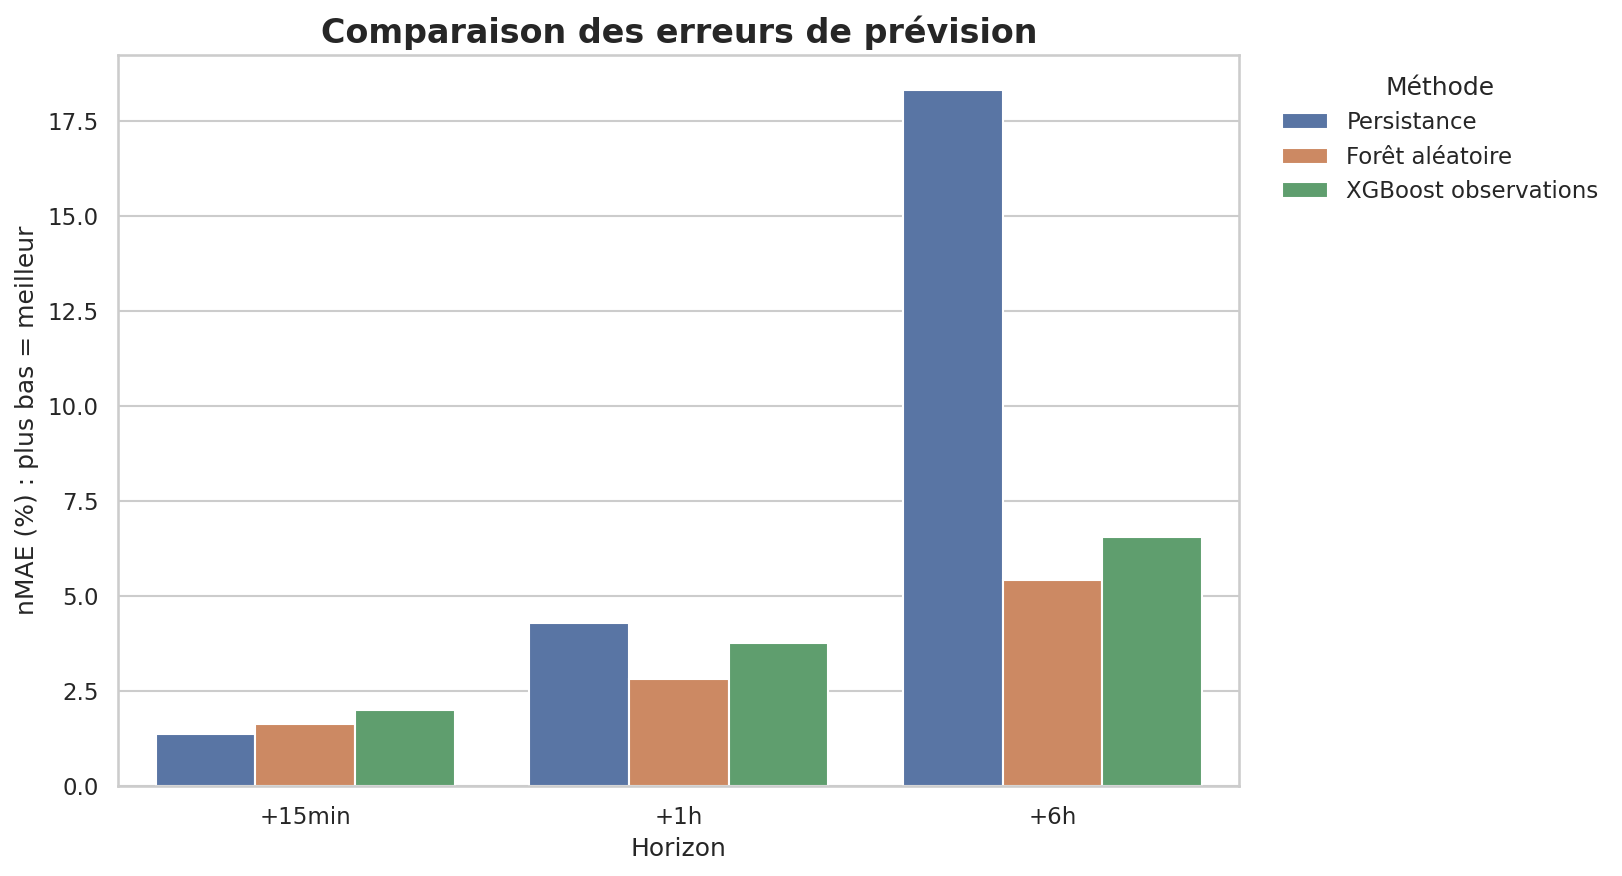

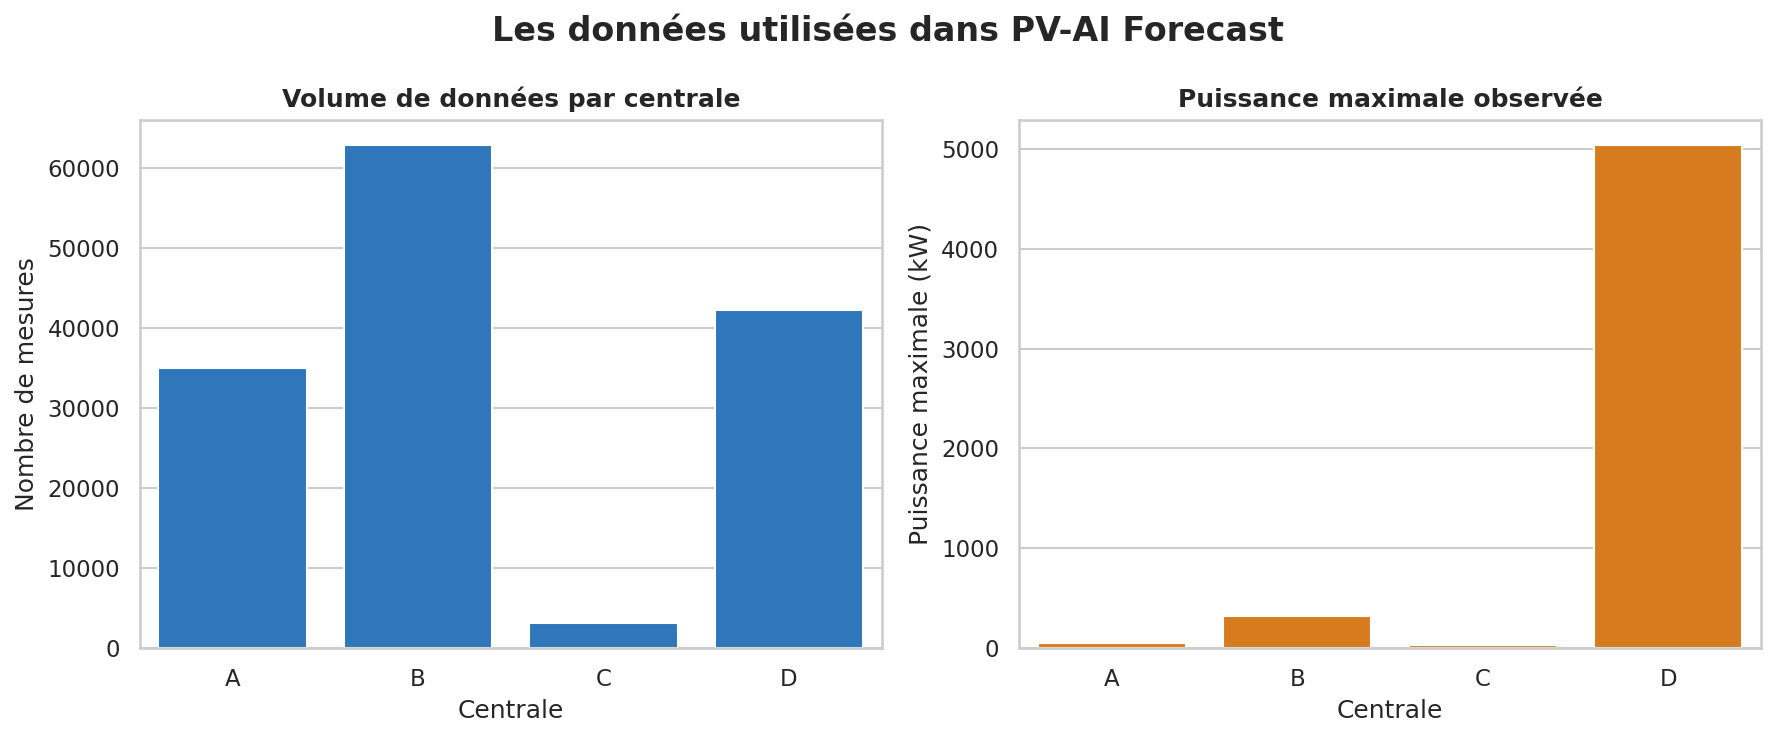

Graphiques et données créés dans le dossier figures_publication :
 - 01_erreur_par_horizon.png
 - 02_gain_vs_persistance.png
 - 03_comparaison_modeles.png
 - 04_resume_datasets.png
 - 05_generalization_performance_comparison.png
 - 06_ablation_study_plot.png
 - 07_shap_bar_plot.png
 - 08_shap_beeswarm_plot.png
 - 09_transfer_matrix_heatmap.png
 - 10_br_pvgen_inverter_study.png
 - df_ablation_study.csv
 - df_br_pvgen_summary.csv
 - df_dataset_audit.csv
 - df_master_results.csv
 - df_transfer_matrix.csv
 - df_walkforward_validation_solartech.csv


In [150]:
import os

# Création du dossier pour les figures et données de publication
output_dir = 'figures_publication'
os.makedirs(output_dir, exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook')

# Utiliser les résultats recalculés, puis harmoniser les noms affichés.
plot_results = pd.concat([df_results_ml, df_results_dl], ignore_index=True).copy()
plot_results['Horizon'] = pd.Categorical(
    plot_results['Horizon'], ['+15min', '+1h', '+6h'], ordered=True
)
plot_results['Modèle court'] = plot_results['Modèle'].replace({
    '1. Persistance simple': 'Persistance',
    '2. Persistance corrigée par le soleil': 'Persistance solaire',
    '3. Moyenne par heure': 'Moyenne horaire',
    '4. Régression Ridge': 'Ridge',
    '5. Forêt aléatoire': 'Forêt aléatoire',
    '6. XGBoost observations': 'XGBoost observations',
    '7. XGBoost météo future idéale': 'XGBoost météo idéale',
})

# 1. Évolution de l'erreur selon l'horizon.
plt.figure(figsize=(10, 6), dpi=150)
sns.lineplot(
    data=plot_results,
    x='Horizon', y='nMAE(%)', hue='Modèle court', marker='o', linewidth=2.5
)
plt.title('Prévision solaire : erreur selon l’horizon', fontsize=16, fontweight='bold')
plt.xlabel('Horizon de prévision')
plt.ylabel('Erreur moyenne nMAE (%)')
plt.legend(title='Modèle', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '01_erreur_par_horizon.png'), dpi=300, bbox_inches='tight')
plt.show()

# 2. Gain des modèles d'apprentissage par rapport à la persistance.
model_results = plot_results[plot_results['Famille'].isin(['ML-Obs', 'ML-NWP', 'DeepLearning'])]
plt.figure(figsize=(10, 6), dpi=150)
sns.barplot(data=model_results, x='Horizon', y='Skill(%)', hue='Modèle court')
plt.axhline(0, color='black', linewidth=1)
plt.title('Gain par rapport à la persistance', fontsize=16, fontweight='bold')
plt.xlabel('Horizon de prévision')
plt.ylabel('Skill (%) : positif = meilleur')
plt.legend(title='Modèle', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '02_gain_vs_persistance.png'), dpi=300, bbox_inches='tight')
plt.show()

# 3. Comparaison simple des méthodes les plus importantes.
model_names = ['Persistance', 'Forêt aléatoire', 'XGBoost observations', 'XGBoost météo idéale']
summary_models = plot_results[plot_results['Modèle court'].isin(model_names)]
plt.figure(figsize=(11, 6), dpi=150)
sns.barplot(data=summary_models, x='Horizon', y='nMAE(%)', hue='Modèle court')
plt.title('Comparaison des erreurs de prévision', fontsize=16, fontweight='bold')
plt.xlabel('Horizon')
plt.ylabel('nMAE (%) : plus bas = meilleur')
plt.legend(title='Méthode', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '03_comparaison_modeles.png'), dpi=300, bbox_inches='tight')
plt.show()

# 4. Vue d'ensemble des données utilisées.
dataset_summary = pd.DataFrame([
    {
        'Jeu': code_ds,
        'Nombre de mesures': len(dataset),
        'Puissance maximale (kW)': dataset['power_kw'].max()
    }
    for code_ds, dataset in raw_datasets.items()
])

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)
sns.barplot(data=dataset_summary, x='Jeu', y='Nombre de mesures', ax=axes[0], color='#1976D2')
axes[0].set_title('Volume de données par centrale', fontweight='bold')
axes[0].set_xlabel('Centrale')
axes[0].set_ylabel('Nombre de mesures')
sns.barplot(data=dataset_summary, x='Jeu', y='Puissance maximale (kW)', ax=axes[1], color='#F57C00')
axes[1].set_title('Puissance maximale observée', fontweight='bold')
axes[1].set_xlabel('Centrale')
axes[1].set_ylabel('Puissance maximale (kW)')
plt.suptitle('Les données utilisées dans PV-AI Forecast', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '04_resume_datasets.png'), dpi=300, bbox_inches='tight')
plt.show()

# Sauvegarde des DataFrames clés pour la publication
df_master_results.to_csv(os.path.join(output_dir, 'df_master_results.csv'), index=False)
df_ablation.to_csv(os.path.join(output_dir, 'df_ablation_study.csv'), index=False)
df_br_pvgen_summary.to_csv(os.path.join(output_dir, 'df_br_pvgen_summary.csv'), index=False)
df_walkforward.to_csv(os.path.join(output_dir, 'df_walkforward_validation_solartech.csv'), index=False)
df_transfer_matrix.to_csv(os.path.join(output_dir, 'df_transfer_matrix.csv'), index=False)
dataset_audit.to_csv(os.path.join(output_dir, 'df_dataset_audit.csv'), index=False)

print(f'Graphiques et données créés dans le dossier {output_dir} :')
for filename in sorted(os.listdir(output_dir)):
    print(f' - {filename}')